# NIFTY Options IV Surface Reconstruction — Comprehensive EDA Dashboard

This notebook is built for the uploaded Kaggle competition files:

- `dataset.csv`
- `sandbox_solution.csv`
- `submission-converter.ipynb`

The notebook is intentionally **EDA-only**.

It does **not** train a model, predict IV, fill missing values, or generate a submission.  
The goal is to understand the structure of the IV surface and the missingness pattern before you design a reconstruction method.

Main questions this notebook investigates:

1. What exactly is inside the dataset?
2. How are the option columns structured by strike/type?
3. How much IV is missing and where?
4. Is missingness random, or does it depend on strike, moneyness, time, or option type?
5. How does the underlying move over the sample?
6. What do the observed IV distributions look like?
7. How do IV smiles/skews behave across time?
8. Do observed IVs show smooth surface structure?
9. Are there obvious static no-arbitrage diagnostic violations in observed data?
10. What modeling risks should be avoided later, especially look-ahead bias?

> Important: any temporary interpolation inside plots is used only to make diagnostics readable. It is clearly marked and is not a prediction pipeline.

## 0. Setup

In [39]:
# Core imports
import os
import re
import math
import warnings
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

# File paths
DATA_PATH = Path("dataset.csv")
SANDBOX_SOLUTION_PATH = Path("sandbox_solution.csv")
CONVERTER_PATH = Path("submission-converter.ipynb")

print("Current working directory:", Path.cwd())
print("dataset.csv exists:", DATA_PATH.exists())
print("sandbox_solution.csv exists:", SANDBOX_SOLUTION_PATH.exists())
print("submission-converter.ipynb exists:", CONVERTER_PATH.exists())

Current working directory: .
dataset.csv exists: True
sandbox_solution.csv exists: True
submission-converter.ipynb exists: True


In [40]:
# Load data
if not DATA_PATH.exists():
    raise FileNotFoundError("dataset.csv not found. Put dataset.csv in the same folder as this notebook.")

raw = pd.read_csv(DATA_PATH)
df = raw.copy()

print("Raw dataset shape:", df.shape)
display(df.head())
display(df.tail())

Raw dataset shape: (975, 30)


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,0.09864,0.09511,0.09304,0.09123,NaN,0.08843,0.18174,NaN,0.17206,0.16502,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,0.09896,NaN,0.09412,0.09136,0.09014,0.08885,0.18193,NaN,0.17226,0.16522,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
970,27-01-2026 15:05,25134.65,0.20763,0.42034,0.58577,0.74767,0.96576,1.10655,1.20840,1.45281,1.62229,1.78968,1.85084,NaN,2.16189,2.31529,2.60916,2.34411,NaN,NaN,NaN,1.68275,1.44213,NaN,1.11695,0.95237,0.75249,0.56259,0.35433,0.11644
971,27-01-2026 15:10,25154.95,0.16803,0.40933,NaN,0.82645,NaN,1.12661,NaN,1.58429,NaN,1.96159,2.03204,2.33020,2.38021,2.55189,2.71129,NaN,NaN,2.13747,2.13017,1.85502,1.65228,1.44843,1.24310,0.97402,0.82574,NaN,0.40968,0.17324
972,27-01-2026 15:15,25174.85,0.14225,0.42629,0.67450,0.81392,1.03772,1.33488,1.47205,NaN,NaN,2.22048,2.30421,2.50644,NaN,2.90515,3.17201,2.95157,2.88296,2.51011,2.41940,2.06703,1.84445,1.62086,1.39592,1.16917,1.00123,0.75534,NaN,0.23712
973,27-01-2026 15:20,25198.10,0.01680,0.39816,0.69406,NaN,1.20671,1.47601,1.84647,2.00071,NaN,2.65570,2.76165,NaN,NaN,3.69076,NaN,NaN,3.40433,3.13418,2.86358,2.59234,2.32024,2.04698,1.77218,1.49530,1.21558,NaN,0.68798,0.34040
974,27-01-2026 15:25,25242.40,0.03726,0.35816,0.73157,1.13908,1.53259,1.91634,2.29252,2.66246,3.02705,NaN,3.74259,NaN,NaN,NaN,NaN,5.38476,4.97453,4.59339,4.21172,3.82927,3.44575,3.06078,2.67390,2.28444,1.89151,NaN,1.08871,NaN


## 1. Dataset structure and first sanity checks

We first check the basic table structure.

Expected from the competition description:

- `datetime`: no missing values
- `underlying_price`: no missing values
- option IV columns: some missing values
- IV values should be positive decimals, for example `0.113 = 11.3%`

In [41]:
print("Columns:")
for i, col in enumerate(df.columns):
    print(f"{i:02d}: {col}")

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
    "n_unique": df.nunique(dropna=True)
})
display(summary)

print("Duplicate full rows:", df.duplicated().sum())
print("Duplicate datetimes:", df["datetime"].duplicated().sum())

Columns:
00: datetime
01: underlying_price
02: NIFTY27JAN2625200CE
03: NIFTY27JAN2625300CE
04: NIFTY27JAN2625400CE
05: NIFTY27JAN2625500CE
06: NIFTY27JAN2625600CE
07: NIFTY27JAN2625700CE
08: NIFTY27JAN2625800CE
09: NIFTY27JAN2625900CE
10: NIFTY27JAN2626000CE
11: NIFTY27JAN2626100CE
12: NIFTY27JAN2626200CE
13: NIFTY27JAN2626300CE
14: NIFTY27JAN2626400CE
15: NIFTY27JAN2626500CE
16: NIFTY27JAN2623800PE
17: NIFTY27JAN2623900PE
18: NIFTY27JAN2624000PE
19: NIFTY27JAN2624100PE
20: NIFTY27JAN2624200PE
21: NIFTY27JAN2624300PE
22: NIFTY27JAN2624400PE
23: NIFTY27JAN2624500PE
24: NIFTY27JAN2624600PE
25: NIFTY27JAN2624700PE
26: NIFTY27JAN2624800PE
27: NIFTY27JAN2624900PE
28: NIFTY27JAN2625000PE
29: NIFTY27JAN2625100PE


,dtype,missing_count,missing_rate,n_unique
datetime,str,0,0.000000,975
underlying_price,float64,0,0.000000,955
NIFTY27JAN2625200CE,float64,194,0.198974,747
NIFTY27JAN2625300CE,float64,184,0.188718,730
NIFTY27JAN2625400CE,float64,202,0.207179,707
NIFTY27JAN2625500CE,float64,181,0.185641,726
NIFTY27JAN2625600CE,float64,180,0.184615,712
NIFTY27JAN2625700CE,float64,201,0.206154,705
NIFTY27JAN2625800CE,float64,210,0.215385,698
NIFTY27JAN2625900CE,float64,182,0.186667,717


Duplicate full rows: 0
Duplicate datetimes: 0


In [42]:
# Parse datetime exactly as competition describes: DD-MM-YYYY HH:MM
df["datetime"] = pd.to_datetime(df["datetime"], format="%d-%m-%Y %H:%M", errors="coerce")

print("Unparsed datetime count:", df["datetime"].isna().sum())

df = df.sort_values("datetime").reset_index(drop=True)

print("Start:", df["datetime"].min())
print("End:  ", df["datetime"].max())
print("Number of unique trading dates:", df["datetime"].dt.date.nunique())

display(
    df["datetime"].dt.date.value_counts()
    .sort_index()
    .rename_axis("date")
    .to_frame("rows")
)

Unparsed datetime count: 0
Start: 2026-01-07 09:15:00
End:   2026-01-27 15:25:00
Number of unique trading dates: 13


,rows
date,
2026-01-07,75
2026-01-08,75
2026-01-09,75
2026-01-12,75
2026-01-13,75
2026-01-14,75
2026-01-16,75
2026-01-19,75
2026-01-20,75


Most common gaps across full dataset:


,count
datetime,
0 days 00:05:00,962
0 days 17:50:00,8
2 days 17:50:00,2
1 days 17:50:00,1
3 days 17:50:00,1


Most common gaps within each trading day:


,count
datetime,
0 days 00:05:00,962


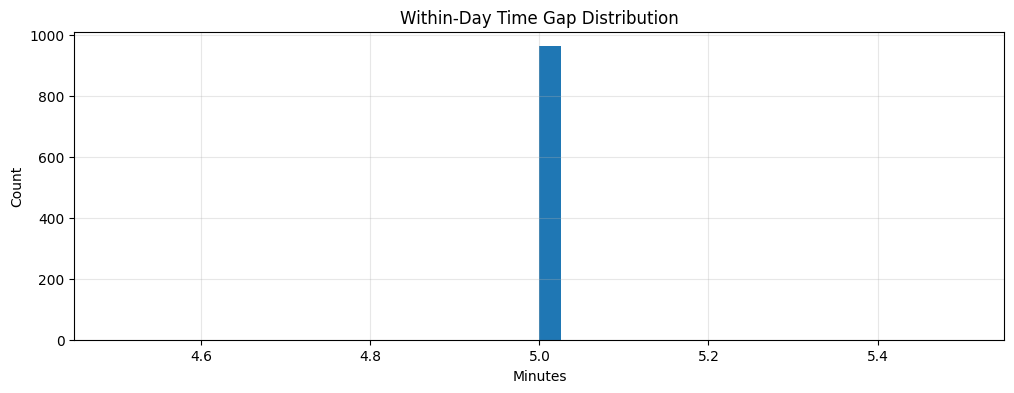

In [43]:
# Check 5-minute spacing within trading days
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time

all_gaps = df["datetime"].diff()
same_day_gaps = df.groupby("date")["datetime"].diff()

print("Most common gaps across full dataset:")
display(all_gaps.value_counts().head(10).to_frame("count"))

print("Most common gaps within each trading day:")
display(same_day_gaps.value_counts().head(10).to_frame("count"))

plt.figure(figsize=(12, 4))
same_day_gaps.dropna().dt.total_seconds().div(60).plot(kind="hist", bins=40)
plt.title("Within-Day Time Gap Distribution")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Parse option tickers into expiry, strike, and option type

Each option column name encodes contract information.

Example:

```text
NIFTY27JAN2625200CE
```

means:

- Index: NIFTY
- Expiry: 27 Jan 2026
- Strike: 25200
- Type: CE, call option

This metadata is essential for surface EDA.

In [44]:
id_cols = ["datetime", "underlying_price"]
option_cols = [c for c in df.columns if c not in id_cols + ["date", "time"]]

ticker_pattern = re.compile(
    r"^(?P<underlying>[A-Z]+)(?P<expiry>\d{2}[A-Z]{3}\d{2})(?P<strike>\d+)(?P<option_type>CE|PE)$"
)

records = []
bad_cols = []

for col in option_cols:
    m = ticker_pattern.match(col)
    if m is None:
        bad_cols.append(col)
        continue

    rec = m.groupdict()
    rec["column"] = col
    rec["strike"] = int(rec["strike"])
    rec["expiry"] = pd.to_datetime(rec["expiry"], format="%d%b%y", errors="coerce")
    records.append(rec)

meta = pd.DataFrame(records)

print("Number of option columns:", len(option_cols))
print("Successfully parsed:", len(meta))
print("Failed to parse:", bad_cols)

display(meta.sort_values(["option_type", "strike"]).reset_index(drop=True))

print("Strike coverage by option type:")
display(meta.groupby("option_type")["strike"].agg(["min", "max", "count", "nunique"]))

print("Expiry dates found:")
display(meta["expiry"].value_counts().to_frame("num_columns"))

Number of option columns: 28
Successfully parsed: 28
Failed to parse: []


,underlying,expiry,strike,option_type,column
0,NIFTY,2026-01-27,25200,CE,NIFTY27JAN2625200CE
1,NIFTY,2026-01-27,25300,CE,NIFTY27JAN2625300CE
2,NIFTY,2026-01-27,25400,CE,NIFTY27JAN2625400CE
3,NIFTY,2026-01-27,25500,CE,NIFTY27JAN2625500CE
4,NIFTY,2026-01-27,25600,CE,NIFTY27JAN2625600CE
5,NIFTY,2026-01-27,25700,CE,NIFTY27JAN2625700CE
6,NIFTY,2026-01-27,25800,CE,NIFTY27JAN2625800CE
7,NIFTY,2026-01-27,25900,CE,NIFTY27JAN2625900CE
8,NIFTY,2026-01-27,26000,CE,NIFTY27JAN2626000CE
9,NIFTY,2026-01-27,26100,CE,NIFTY27JAN2626100CE


Strike coverage by option type:


,min,max,count,nunique
option_type,,,,
CE,25200,26500,14,14
PE,23800,25100,14,14


Expiry dates found:


,num_columns
expiry,
2026-01-27,28


Calls: 14 columns
Puts:  14 columns


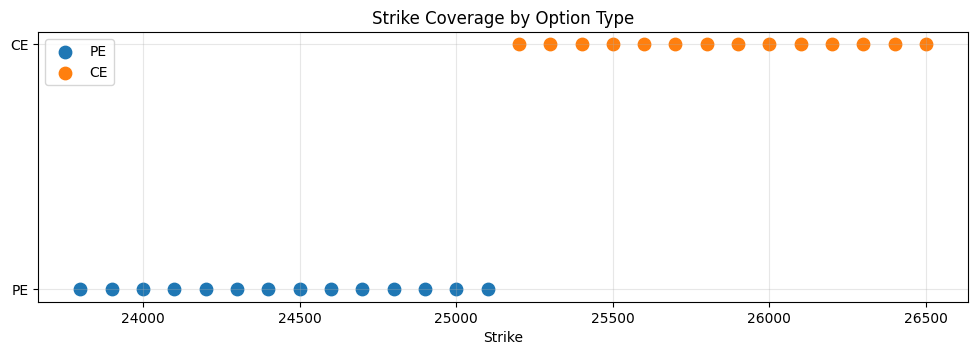

In [45]:
# Ordered option columns: puts by increasing strike, then calls by increasing strike
ordered_meta = meta.sort_values(["option_type", "strike"], ascending=[False, True]).reset_index(drop=True)
ordered_cols = ordered_meta["column"].tolist()

call_meta = meta[meta["option_type"] == "CE"].sort_values("strike").reset_index(drop=True)
put_meta = meta[meta["option_type"] == "PE"].sort_values("strike").reset_index(drop=True)

call_cols = call_meta["column"].tolist()
put_cols = put_meta["column"].tolist()

print(f"Calls: {len(call_cols)} columns")
print(f"Puts:  {len(put_cols)} columns")

plt.figure(figsize=(12, 3.5))
for option_type, y in [("PE", 0), ("CE", 1)]:
    sub = meta[meta["option_type"] == option_type]
    plt.scatter(sub["strike"], np.full(len(sub), y), s=80, label=option_type)
plt.yticks([0, 1], ["PE", "CE"])
plt.xlabel("Strike")
plt.title("Strike Coverage by Option Type")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Time-to-expiry and moneyness context

For options, strike alone is not enough.

A 25200 strike behaves differently when spot is 24950 versus 26100.

So we create:

```text
moneyness = strike / underlying_price
log_moneyness = log(strike / underlying_price)
```

We also compute approximate calendar days to expiry.

This is EDA context only.

In [46]:
expiry_values = meta["expiry"].dropna().unique()
if len(expiry_values) != 1:
    print("Warning: multiple or zero expiries found:", expiry_values)

EXPIRY_DATE = pd.Timestamp(expiry_values[0])
df["days_to_expiry"] = (EXPIRY_DATE - df["datetime"]).dt.total_seconds() / (24 * 3600)
df["years_to_expiry"] = df["days_to_expiry"] / 365.0

print("Expiry date:", EXPIRY_DATE)
display(df[["datetime", "underlying_price", "days_to_expiry", "years_to_expiry"]].head())
display(df[["datetime", "underlying_price", "days_to_expiry", "years_to_expiry"]].tail())

print("Underlying price summary:")
display(df["underlying_price"].describe().to_frame("underlying_price"))

Expiry date: 2026-01-27 00:00:00


,datetime,underlying_price,days_to_expiry,years_to_expiry
0,2026-01-07 09:15:00,26111.65,19.614583,0.053739
1,2026-01-07 09:20:00,26141.40,19.611111,0.053729
2,2026-01-07 09:25:00,26139.35,19.607639,0.053720
3,2026-01-07 09:30:00,26128.95,19.604167,0.053710
4,2026-01-07 09:35:00,26131.90,19.600694,0.053701


,datetime,underlying_price,days_to_expiry,years_to_expiry
970,2026-01-27 15:05:00,25134.65,-0.628472,-0.001722
971,2026-01-27 15:10:00,25154.95,-0.631944,-0.001731
972,2026-01-27 15:15:00,25174.85,-0.635417,-0.001741
973,2026-01-27 15:20:00,25198.10,-0.638889,-0.001750
974,2026-01-27 15:25:00,25242.40,-0.642361,-0.001760


Underlying price summary:


,underlying_price
count,975.000000
mean,25564.155846
std,317.642518
min,24940.700000
25%,25266.850000
50%,25624.200000
75%,25768.200000
max,26183.800000


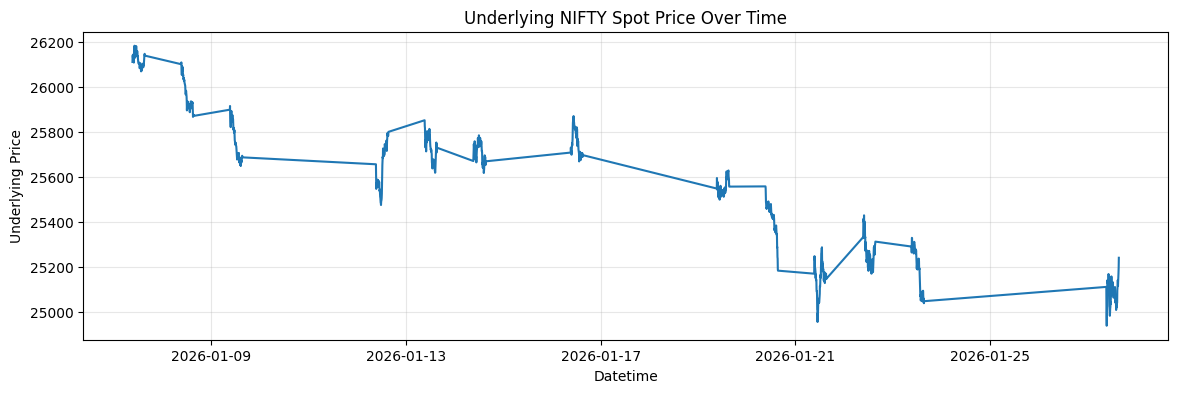

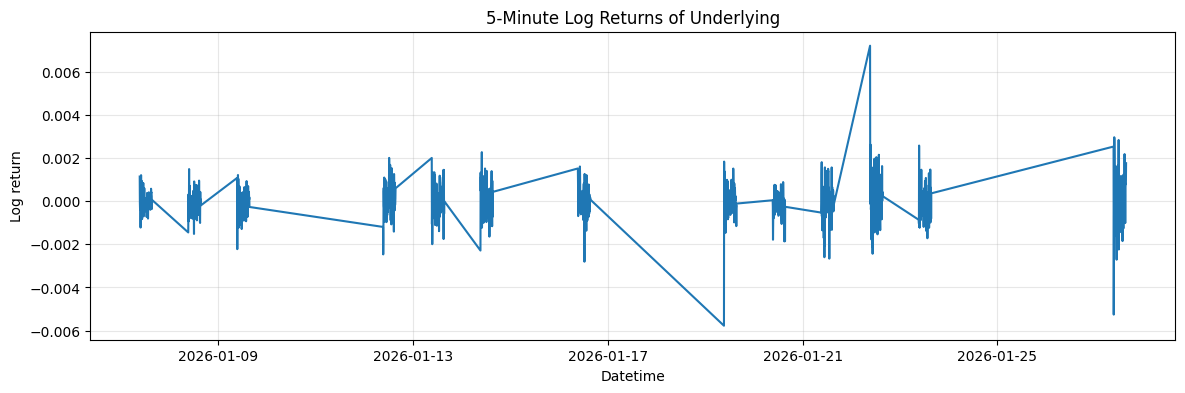

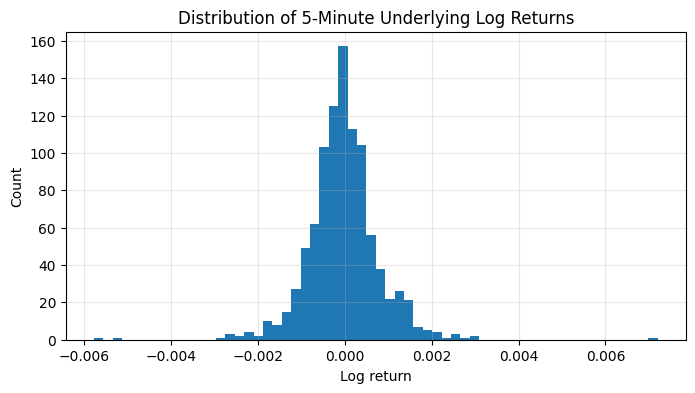

In [47]:
plt.figure(figsize=(14, 4))
plt.plot(df["datetime"], df["underlying_price"])
plt.title("Underlying NIFTY Spot Price Over Time")
plt.xlabel("Datetime")
plt.ylabel("Underlying Price")
plt.grid(True, alpha=0.3)
plt.show()

# Intraday returns
df["underlying_log_return"] = np.log(df["underlying_price"]).diff()

plt.figure(figsize=(14, 4))
plt.plot(df["datetime"], df["underlying_log_return"])
plt.title("5-Minute Log Returns of Underlying")
plt.xlabel("Datetime")
plt.ylabel("Log return")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
df["underlying_log_return"].dropna().plot(kind="hist", bins=60)
plt.title("Distribution of 5-Minute Underlying Log Returns")
plt.xlabel("Log return")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Overall missingness dashboard

This is the most important first pass for this competition.

We inspect missingness by:

- whole dataset
- option column
- option type
- strike
- timestamp
- trading date
- time of day

This helps answer whether missingness appears random or structurally related to the option chain.

In [48]:
iv = df[option_cols]

total_iv_cells = iv.shape[0] * iv.shape[1]
missing_iv_cells = int(iv.isna().sum().sum())
observed_iv_cells = total_iv_cells - missing_iv_cells

print("IV matrix shape:", iv.shape)
print("Total IV cells:", total_iv_cells)
print("Observed IV cells:", observed_iv_cells)
print("Missing IV cells:", missing_iv_cells)
print("Overall IV missing rate:", missing_iv_cells / total_iv_cells)

missing_by_col = (
    iv.isna().sum()
    .rename("missing_count")
    .to_frame()
)
missing_by_col["missing_rate"] = missing_by_col["missing_count"] / len(df)
missing_by_col = missing_by_col.join(meta.set_index("column")[["strike", "option_type", "expiry"]])
missing_by_col = missing_by_col.sort_values("missing_rate", ascending=False)

display(missing_by_col)

IV matrix shape: (975, 28)
Total IV cells: 27300
Observed IV cells: 21840
Missing IV cells: 5460
Overall IV missing rate: 0.2


,missing_count,missing_rate,strike,option_type,expiry
NIFTY27JAN2624200PE,217,0.222564,24200,PE,2026-01-27
NIFTY27JAN2626400CE,213,0.218462,26400,CE,2026-01-27
NIFTY27JAN2625800CE,210,0.215385,25800,CE,2026-01-27
NIFTY27JAN2626200CE,209,0.214359,26200,CE,2026-01-27
NIFTY27JAN2624800PE,209,0.214359,24800,PE,2026-01-27
NIFTY27JAN2624000PE,209,0.214359,24000,PE,2026-01-27
NIFTY27JAN2625100PE,205,0.210256,25100,PE,2026-01-27
NIFTY27JAN2623800PE,203,0.208205,23800,PE,2026-01-27
NIFTY27JAN2625400CE,202,0.207179,25400,CE,2026-01-27
NIFTY27JAN2624400PE,202,0.207179,24400,PE,2026-01-27


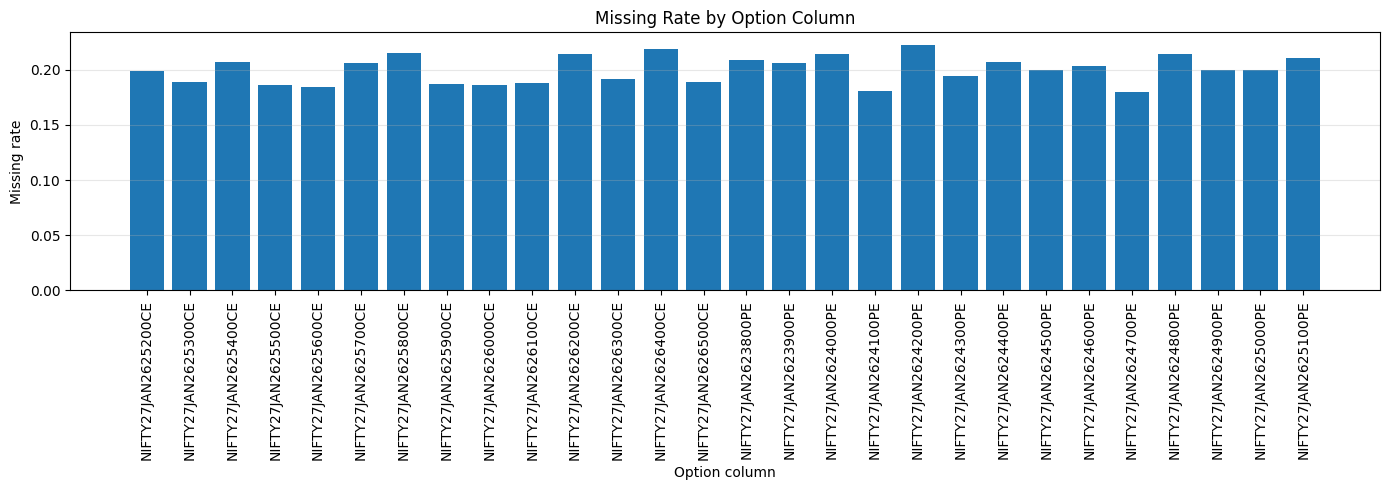

,total_missing_count,avg_column_missing_rate
option_type,,
CE,2691,0.197143
PE,2769,0.202857


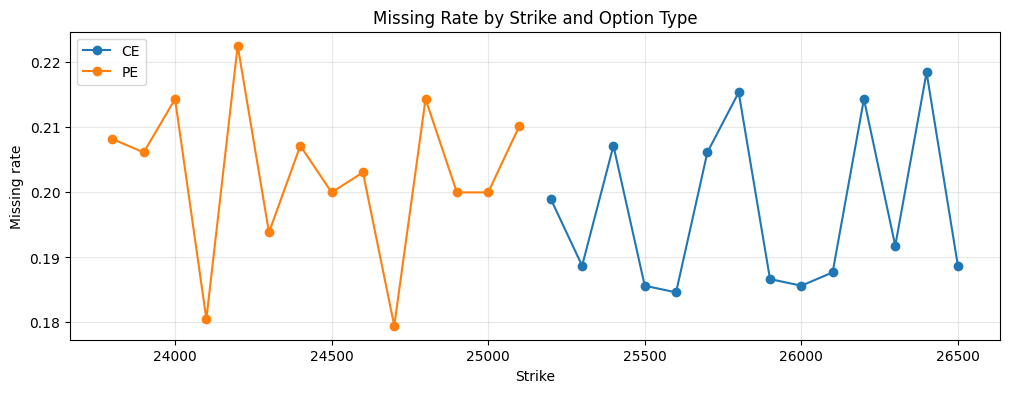

In [49]:
# Missingness by column
plot_df = missing_by_col.sort_values(["option_type", "strike"])

plt.figure(figsize=(14, 5))
plt.bar(plot_df.index, plot_df["missing_rate"])
plt.title("Missing Rate by Option Column")
plt.xlabel("Option column")
plt.ylabel("Missing rate")
plt.xticks(rotation=90)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Missingness by option type
display(
    missing_by_col.groupby("option_type")[["missing_count", "missing_rate"]]
    .agg({"missing_count": "sum", "missing_rate": "mean"})
    .rename(columns={"missing_count": "total_missing_count", "missing_rate": "avg_column_missing_rate"})
)

# Missingness by strike
miss_by_strike = (
    missing_by_col
    .groupby(["option_type", "strike"])["missing_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 4))
for opt_type, sub in miss_by_strike.groupby("option_type"):
    plt.plot(sub["strike"], sub["missing_rate"], marker="o", label=opt_type)
plt.title("Missing Rate by Strike and Option Type")
plt.xlabel("Strike")
plt.ylabel("Missing rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

,datetime,underlying_price,num_missing_iv,missing_rate_iv
0,2026-01-07 09:15:00,26111.65,3,0.107143
1,2026-01-07 09:20:00,26141.40,8,0.285714
2,2026-01-07 09:25:00,26139.35,4,0.142857
3,2026-01-07 09:30:00,26128.95,4,0.142857
4,2026-01-07 09:35:00,26131.90,5,0.178571


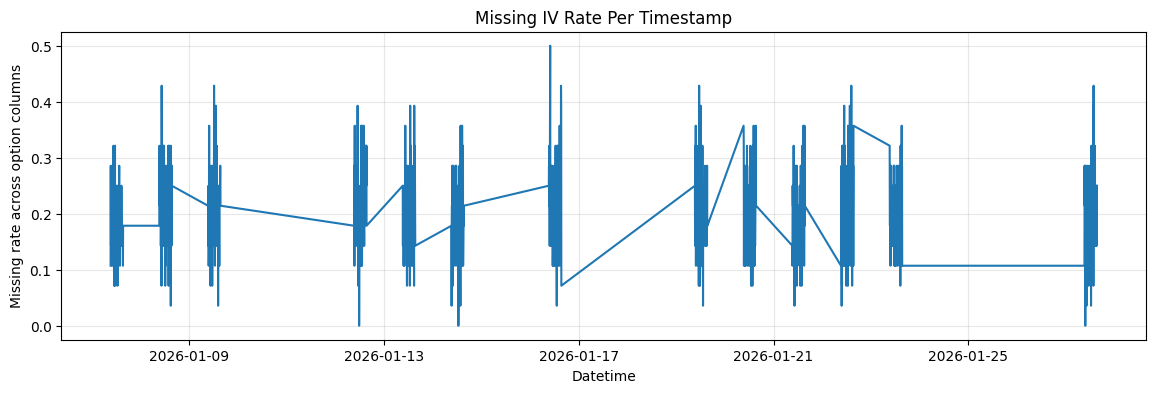

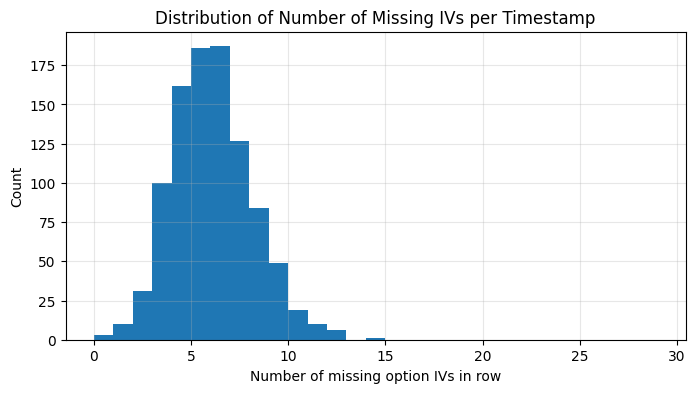

In [50]:
# Missingness by row/time
df["num_missing_iv"] = iv.isna().sum(axis=1)
df["missing_rate_iv"] = df["num_missing_iv"] / len(option_cols)

display(df[["datetime", "underlying_price", "num_missing_iv", "missing_rate_iv"]].head())

plt.figure(figsize=(14, 4))
plt.plot(df["datetime"], df["missing_rate_iv"])
plt.title("Missing IV Rate Per Timestamp")
plt.xlabel("Datetime")
plt.ylabel("Missing rate across option columns")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
df["num_missing_iv"].plot(kind="hist", bins=range(0, len(option_cols)+2))
plt.title("Distribution of Number of Missing IVs per Timestamp")
plt.xlabel("Number of missing option IVs in row")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

,mean,min,max,count
date,,,,
2026-01-07,0.184286,0.071429,0.321429,75
2026-01-08,0.217619,0.035714,0.428571,75
2026-01-09,0.195714,0.035714,0.428571,75
2026-01-12,0.218095,0.000000,0.392857,75
2026-01-13,0.201905,0.071429,0.392857,75
2026-01-14,0.189048,0.000000,0.357143,75
2026-01-16,0.208571,0.035714,0.500000,75
2026-01-19,0.201905,0.035714,0.428571,75
2026-01-20,0.197619,0.071429,0.357143,75


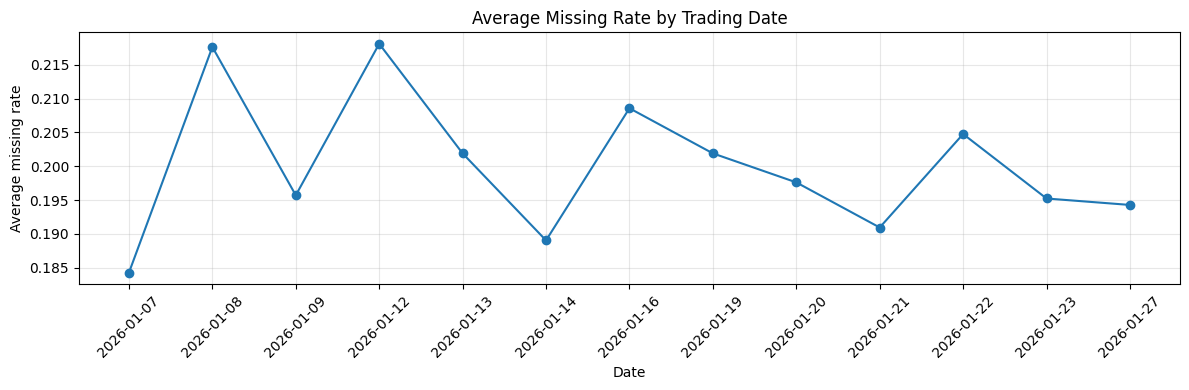

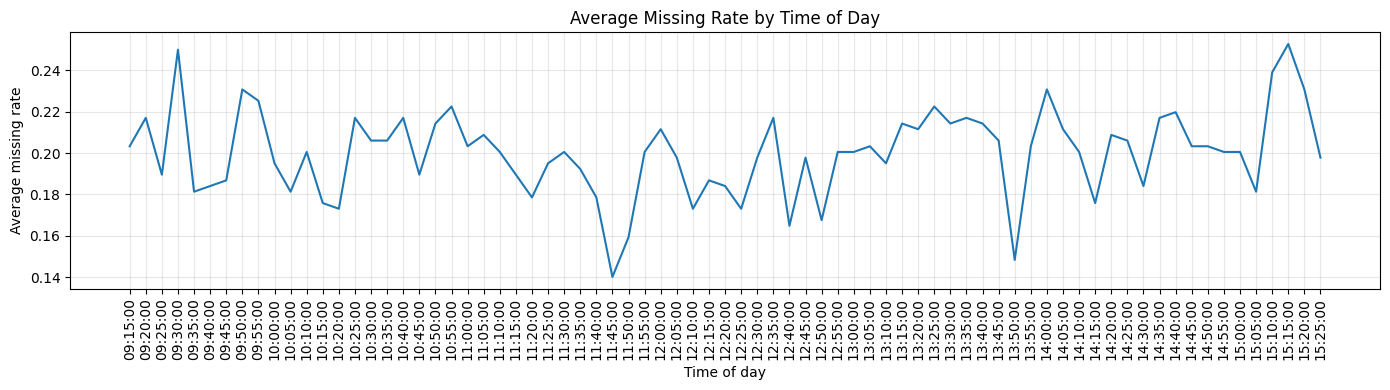

In [51]:
# Missingness by date and time of day
missing_by_date = df.groupby("date")["missing_rate_iv"].agg(["mean", "min", "max", "count"])
display(missing_by_date)

plt.figure(figsize=(12, 4))
plt.plot(missing_by_date.index.astype(str), missing_by_date["mean"], marker="o")
plt.title("Average Missing Rate by Trading Date")
plt.xlabel("Date")
plt.ylabel("Average missing rate")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

missing_by_time = df.groupby("time")["missing_rate_iv"].mean()

plt.figure(figsize=(14, 4))
plt.plot([str(t) for t in missing_by_time.index], missing_by_time.values)
plt.title("Average Missing Rate by Time of Day")
plt.xlabel("Time of day")
plt.ylabel("Average missing rate")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

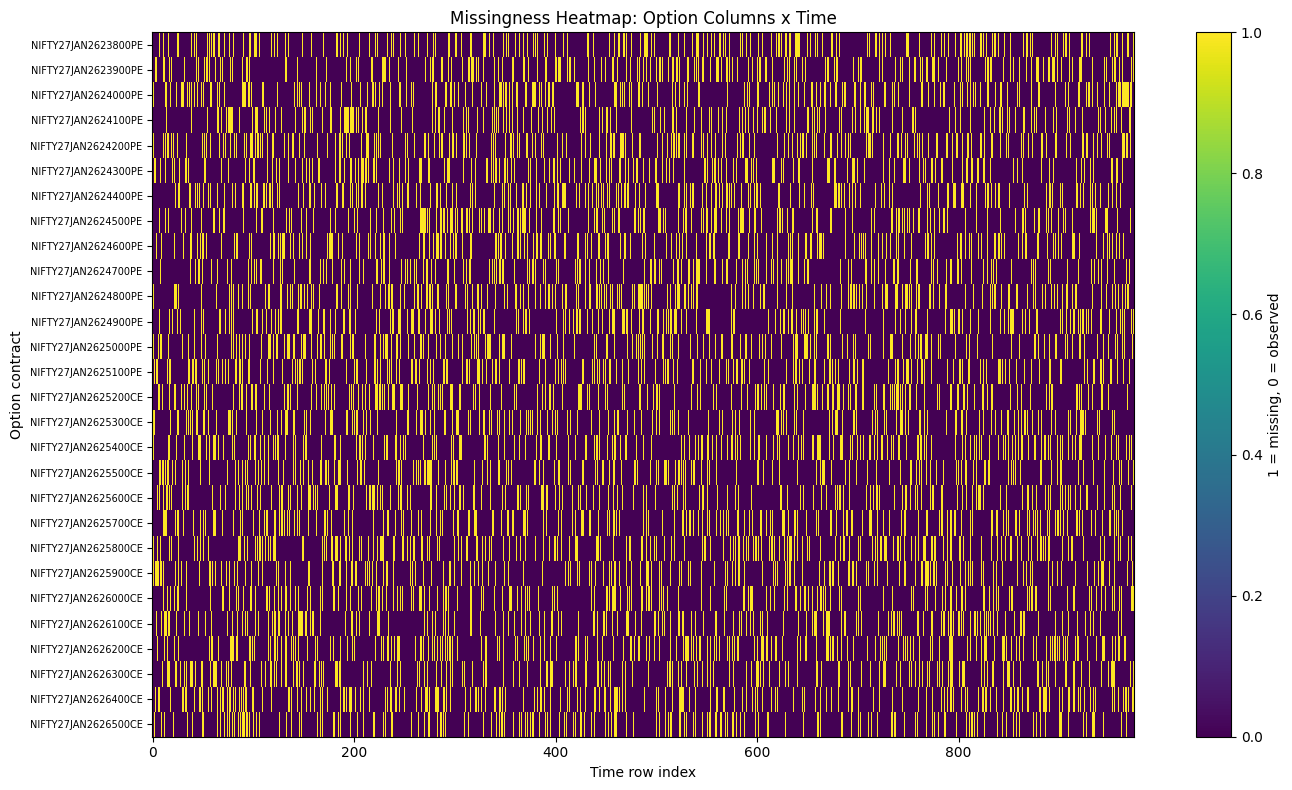

In [52]:
# Missingness heatmap: rows=time, columns=ordered option contracts
missing_matrix = df[ordered_cols].isna().astype(int)

plt.figure(figsize=(14, 8))
plt.imshow(missing_matrix.T, aspect="auto", interpolation="nearest")
plt.title("Missingness Heatmap: Option Columns x Time")
plt.xlabel("Time row index")
plt.ylabel("Option contract")
plt.yticks(range(len(ordered_cols)), ordered_cols, fontsize=7)
plt.colorbar(label="1 = missing, 0 = observed")
plt.tight_layout()
plt.show()

## 5. Submission-format sanity check

The provided `sandbox_solution.csv` is useful for checking the expected submission structure.

We do **not** use it to infer IV values.  
We only verify that the number of rows matches the number of originally missing cells and that IDs follow the expected format:

```text
datetime||option_column
```

In [53]:
if SANDBOX_SOLUTION_PATH.exists():
    sandbox_solution = pd.read_csv(SANDBOX_SOLUTION_PATH)
    print("sandbox_solution shape:", sandbox_solution.shape)
    display(sandbox_solution.head())

    print("Columns:", sandbox_solution.columns.tolist())
    print("Rows in sandbox_solution:", len(sandbox_solution))
    print("Missing IV cells in dataset:", missing_iv_cells)
    print("Do row counts match?", len(sandbox_solution) == missing_iv_cells)

    # Parse IDs
    sep = "||"
    parsed_ids = sandbox_solution["id"].str.split(sep, regex=False, expand=True)
    if parsed_ids.shape[1] == 2:
        parsed_ids.columns = ["datetime_string", "option_column"]
        print("ID parse success.")
        print("Unknown option columns in sandbox_solution:",
              sorted(set(parsed_ids["option_column"]) - set(option_cols))[:10])
        display(parsed_ids.head())
    else:
        print("Could not parse IDs into exactly two parts.")
else:
    print("sandbox_solution.csv not found. Skipping this section.")

sandbox_solution shape: (5460, 2)


,id,value
0,07-01-2026 09:15||NIFTY27JAN2624100PE,0.143129
1,07-01-2026 09:15||NIFTY27JAN2625500CE,0.102447
2,07-01-2026 09:15||NIFTY27JAN2625800CE,0.102447
3,07-01-2026 09:20||NIFTY27JAN2624000PE,0.147267
4,07-01-2026 09:20||NIFTY27JAN2624200PE,0.147267


Columns: ['id', 'value']
Rows in sandbox_solution: 5460
Missing IV cells in dataset: 5460
Do row counts match? True
ID parse success.
Unknown option columns in sandbox_solution: []


,datetime_string,option_column
0,07-01-2026 09:15,NIFTY27JAN2624100PE
1,07-01-2026 09:15,NIFTY27JAN2625500CE
2,07-01-2026 09:15,NIFTY27JAN2625800CE
3,07-01-2026 09:20,NIFTY27JAN2624000PE
4,07-01-2026 09:20,NIFTY27JAN2624200PE


## 6. Observed IV value diagnostics

Now we inspect only observed IV values.

Checks:

- Are all observed IVs positive?
- Are there extreme values?
- Do calls and puts have different distributions?
- Which columns have unusual ranges?

Observed IV count: 27300
Minimum observed IV: 0.0168
Maximum observed IV: 5.38476
Number of non-positive observed IVs: 0


,observed_iv
count,21840.000000
mean,0.182937
std,0.219077
min,0.016800
1%,0.087876
5%,0.094880
25%,0.110040
50%,0.130620
75%,0.168563
95%,0.494619


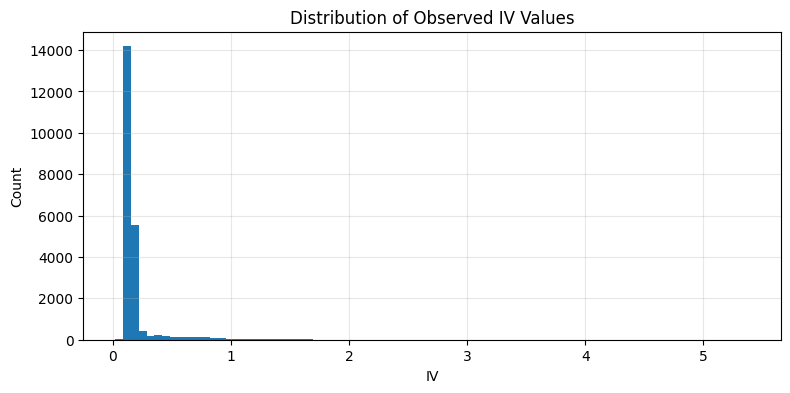

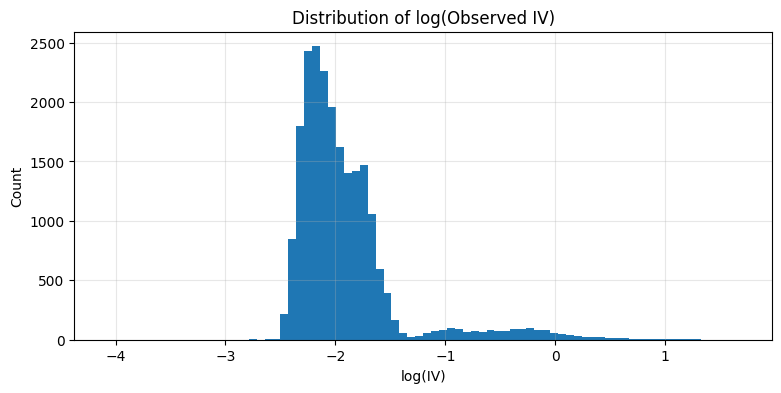

In [54]:
observed_iv_values = iv.stack()

print("Observed IV count:", observed_iv_values.shape[0])
print("Minimum observed IV:", observed_iv_values.min())
print("Maximum observed IV:", observed_iv_values.max())
print("Number of non-positive observed IVs:", (observed_iv_values <= 0).sum())

display(observed_iv_values.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("observed_iv"))

plt.figure(figsize=(9, 4))
observed_iv_values.plot(kind="hist", bins=80)
plt.title("Distribution of Observed IV Values")
plt.xlabel("IV")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
np.log(observed_iv_values).plot(kind="hist", bins=80)
plt.title("Distribution of log(Observed IV)")
plt.xlabel("log(IV)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

,count,mean,std,min,median,max,strike,option_type,missing_rate
NIFTY27JAN2625200CE,781.0,0.140259,0.068745,0.01680,0.122760,0.54896,25200,CE,0.198974
NIFTY27JAN2625300CE,791.0,0.138818,0.075571,0.06317,0.118660,0.57786,25300,CE,0.188718
NIFTY27JAN2625400CE,773.0,0.138240,0.090462,0.07403,0.114480,0.73157,25400,CE,0.207179
NIFTY27JAN2625500CE,794.0,0.142228,0.113038,0.08059,0.112460,1.13908,25500,CE,0.185641
NIFTY27JAN2625600CE,795.0,0.146016,0.141846,0.08180,0.109560,1.53259,25600,CE,0.184615
NIFTY27JAN2625700CE,774.0,0.152041,0.170909,0.08406,0.107620,1.91634,25700,CE,0.206154
NIFTY27JAN2625800CE,765.0,0.160795,0.198059,0.08529,0.106660,2.29252,25800,CE,0.215385
NIFTY27JAN2625900CE,793.0,0.166556,0.222128,0.08600,0.106850,2.66246,25900,CE,0.186667
NIFTY27JAN2626000CE,794.0,0.170306,0.228303,0.08450,0.107955,3.02705,26000,CE,0.185641
NIFTY27JAN2626100CE,792.0,0.184265,0.264587,0.08386,0.108015,2.65570,26100,CE,0.187692


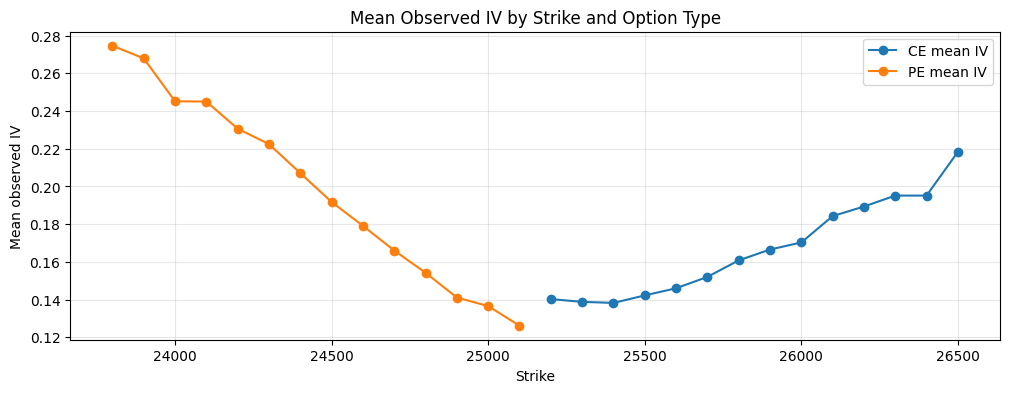

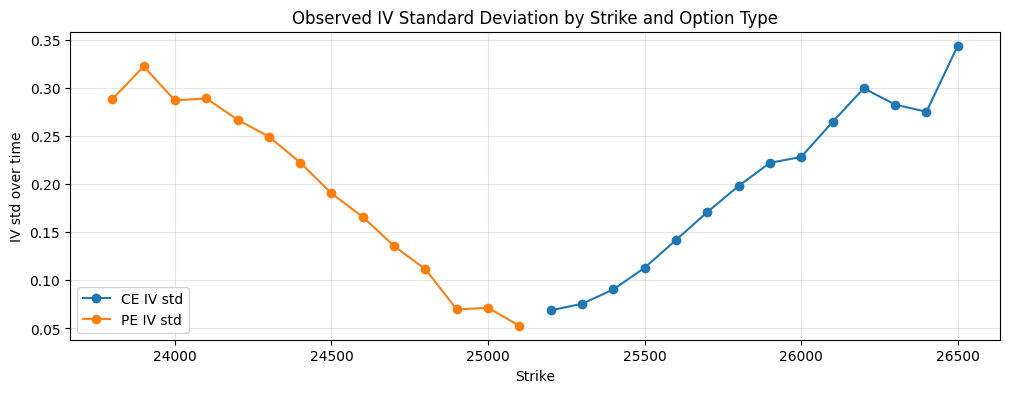

In [55]:
# Column-level observed IV stats
iv_stats = iv.agg(["count", "mean", "std", "min", "median", "max"]).T
iv_stats = iv_stats.join(meta.set_index("column")[["strike", "option_type"]])
iv_stats["missing_rate"] = iv.isna().mean()
iv_stats = iv_stats.sort_values(["option_type", "strike"])

display(iv_stats)

# Mean IV by strike/type
plt.figure(figsize=(12, 4))
for opt_type, sub in iv_stats.groupby("option_type"):
    plt.plot(sub["strike"], sub["mean"], marker="o", label=f"{opt_type} mean IV")
plt.title("Mean Observed IV by Strike and Option Type")
plt.xlabel("Strike")
plt.ylabel("Mean observed IV")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# IV volatility by strike/type
plt.figure(figsize=(12, 4))
for opt_type, sub in iv_stats.groupby("option_type"):
    plt.plot(sub["strike"], sub["std"], marker="o", label=f"{opt_type} IV std")
plt.title("Observed IV Standard Deviation by Strike and Option Type")
plt.xlabel("Strike")
plt.ylabel("IV std over time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

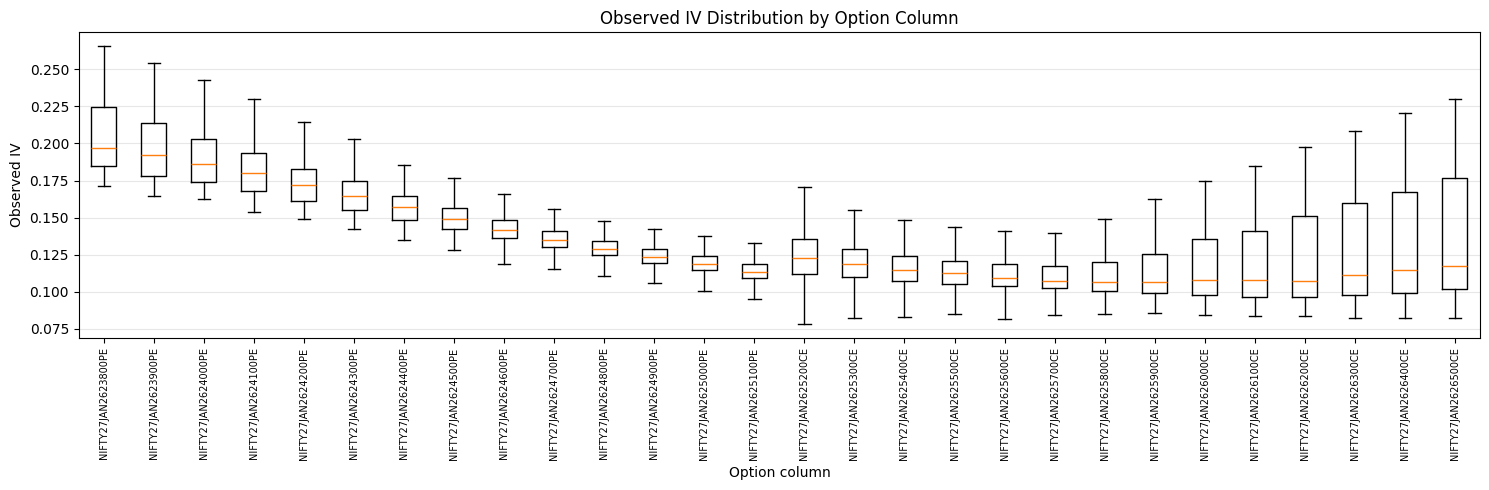

In [56]:
# Boxplots by option column
ordered_stats_cols = meta.sort_values(["option_type", "strike"], ascending=[False, True])["column"].tolist()

plt.figure(figsize=(15, 5))
data_for_boxplot = [df[c].dropna().values for c in ordered_stats_cols]
plt.boxplot(data_for_boxplot, labels=ordered_stats_cols, showfliers=False)
plt.title("Observed IV Distribution by Option Column")
plt.xlabel("Option column")
plt.ylabel("Observed IV")
plt.xticks(rotation=90, fontsize=7)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Moneyness-aware long-format dataset

The wide format is good for Kaggle submission, but long format is better for EDA.

Each row becomes:

```text
timestamp, underlying_price, option column, strike, option type, observed IV
```

Then we add:

```text
moneyness = strike / spot
log_moneyness = log(strike / spot)
abs_log_moneyness = abs(log_moneyness)
```

This makes smile/skew analysis easier.

In [57]:
# Create long observed dataset
long = df[["datetime", "date", "time", "underlying_price", "days_to_expiry"] + option_cols].melt(
    id_vars=["datetime", "date", "time", "underlying_price", "days_to_expiry"],
    value_vars=option_cols,
    var_name="column",
    value_name="iv"
)

long = long.merge(meta[["column", "expiry", "strike", "option_type"]], on="column", how="left")
long["is_missing"] = long["iv"].isna()
long["moneyness"] = long["strike"] / long["underlying_price"]
long["log_moneyness"] = np.log(long["moneyness"])
long["abs_log_moneyness"] = long["log_moneyness"].abs()

observed_long = long.dropna(subset=["iv"]).copy()

print("Long shape:", long.shape)
print("Observed long shape:", observed_long.shape)
display(long.head())
display(observed_long.head())

Long shape: (27300, 14)
Observed long shape: (21840, 14)


,datetime,date,time,underlying_price,days_to_expiry,column,iv,expiry,strike,option_type,is_missing,moneyness,log_moneyness,abs_log_moneyness
0,2026-01-07 09:15:00,2026-01-07,09:15:00,26111.65,19.614583,NIFTY27JAN2625200CE,0.12662,2026-01-27,25200,CE,False,0.965086,-0.035538,0.035538
1,2026-01-07 09:20:00,2026-01-07,09:20:00,26141.40,19.611111,NIFTY27JAN2625200CE,0.08632,2026-01-27,25200,CE,False,0.963988,-0.036676,0.036676
2,2026-01-07 09:25:00,2026-01-07,09:25:00,26139.35,19.607639,NIFTY27JAN2625200CE,0.09147,2026-01-27,25200,CE,False,0.964064,-0.036598,0.036598
3,2026-01-07 09:30:00,2026-01-07,09:30:00,26128.95,19.604167,NIFTY27JAN2625200CE,0.10860,2026-01-27,25200,CE,False,0.964447,-0.036200,0.036200
4,2026-01-07 09:35:00,2026-01-07,09:35:00,26131.90,19.600694,NIFTY27JAN2625200CE,0.10462,2026-01-27,25200,CE,False,0.964339,-0.036313,0.036313


,datetime,date,time,underlying_price,days_to_expiry,column,iv,expiry,strike,option_type,is_missing,moneyness,log_moneyness,abs_log_moneyness
0,2026-01-07 09:15:00,2026-01-07,09:15:00,26111.65,19.614583,NIFTY27JAN2625200CE,0.12662,2026-01-27,25200,CE,False,0.965086,-0.035538,0.035538
1,2026-01-07 09:20:00,2026-01-07,09:20:00,26141.40,19.611111,NIFTY27JAN2625200CE,0.08632,2026-01-27,25200,CE,False,0.963988,-0.036676,0.036676
2,2026-01-07 09:25:00,2026-01-07,09:25:00,26139.35,19.607639,NIFTY27JAN2625200CE,0.09147,2026-01-27,25200,CE,False,0.964064,-0.036598,0.036598
3,2026-01-07 09:30:00,2026-01-07,09:30:00,26128.95,19.604167,NIFTY27JAN2625200CE,0.10860,2026-01-27,25200,CE,False,0.964447,-0.036200,0.036200
4,2026-01-07 09:35:00,2026-01-07,09:35:00,26131.90,19.600694,NIFTY27JAN2625200CE,0.10462,2026-01-27,25200,CE,False,0.964339,-0.036313,0.036313


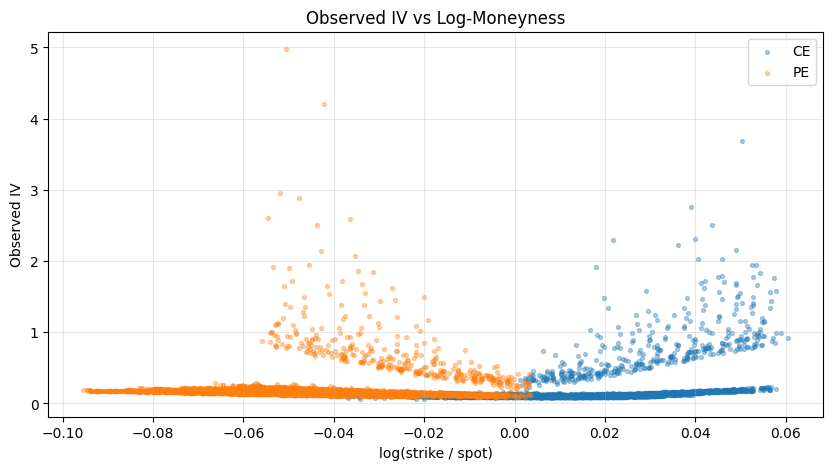

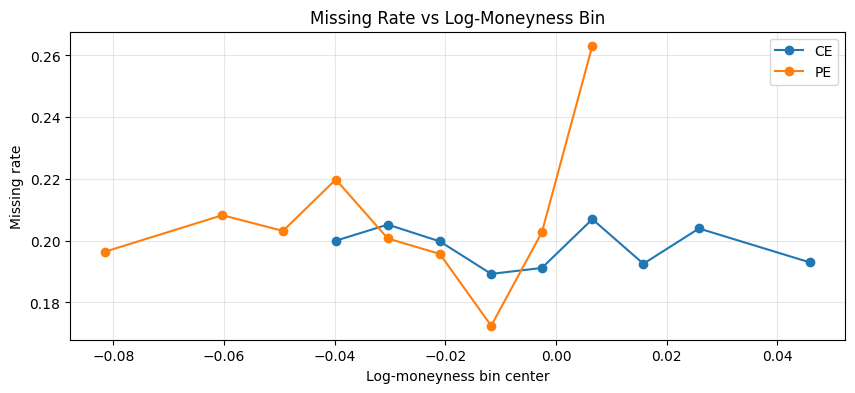

In [58]:
# IV vs moneyness scatter
sample_obs = observed_long.sample(min(10000, len(observed_long)), random_state=42)

plt.figure(figsize=(10, 5))
for opt_type, sub in sample_obs.groupby("option_type"):
    plt.scatter(sub["log_moneyness"], sub["iv"], s=8, alpha=0.35, label=opt_type)
plt.title("Observed IV vs Log-Moneyness")
plt.xlabel("log(strike / spot)")
plt.ylabel("Observed IV")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Missingness vs moneyness
bin_df = long.copy()
bin_df["moneyness_bin"] = pd.qcut(bin_df["log_moneyness"], q=12, duplicates="drop")
miss_by_mny = bin_df.groupby(["option_type", "moneyness_bin"], observed=True)["is_missing"].mean().reset_index()
miss_by_mny["bin_center"] = miss_by_mny["moneyness_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 4))
for opt_type, sub in miss_by_mny.groupby("option_type"):
    plt.plot(sub["bin_center"].astype(float), sub["is_missing"], marker="o", label=opt_type)
plt.title("Missing Rate vs Log-Moneyness Bin")
plt.xlabel("Log-moneyness bin center")
plt.ylabel("Missing rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 8. IV smiles and skews at selected timestamps

For a fixed timestamp, plot observed IV against strike.

Because the dataset has calls and puts on different strike ranges, we plot them separately and together.

This section helps answer:

- Are smiles smooth?
- Are there obvious outliers?
- Does the shape shift as spot moves?
- Does the surface become noisier near expiry?

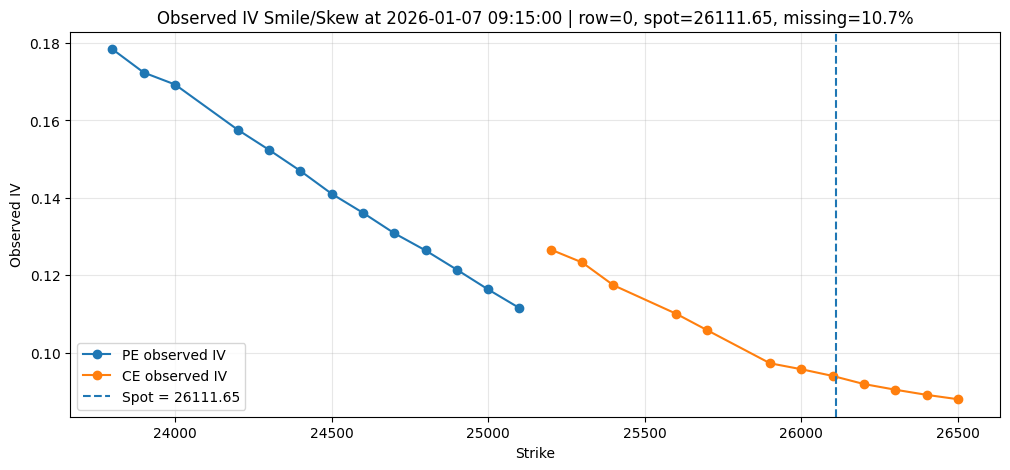

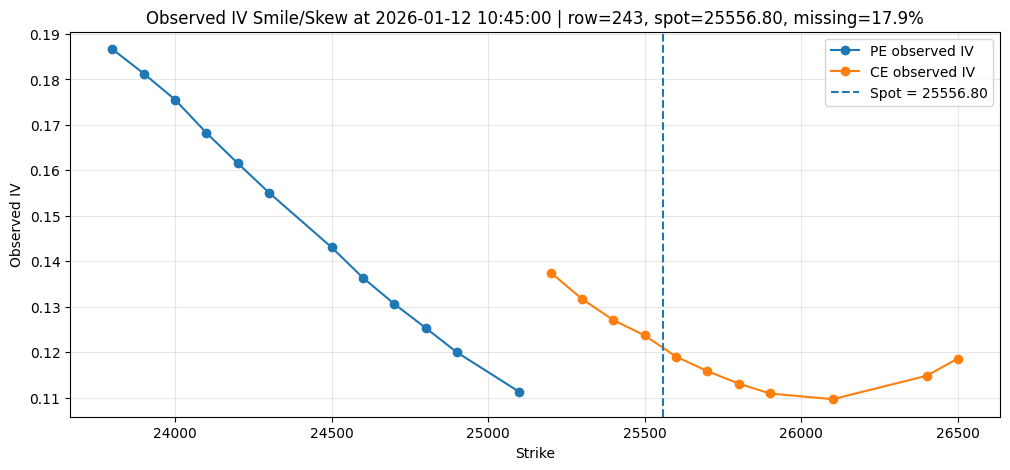

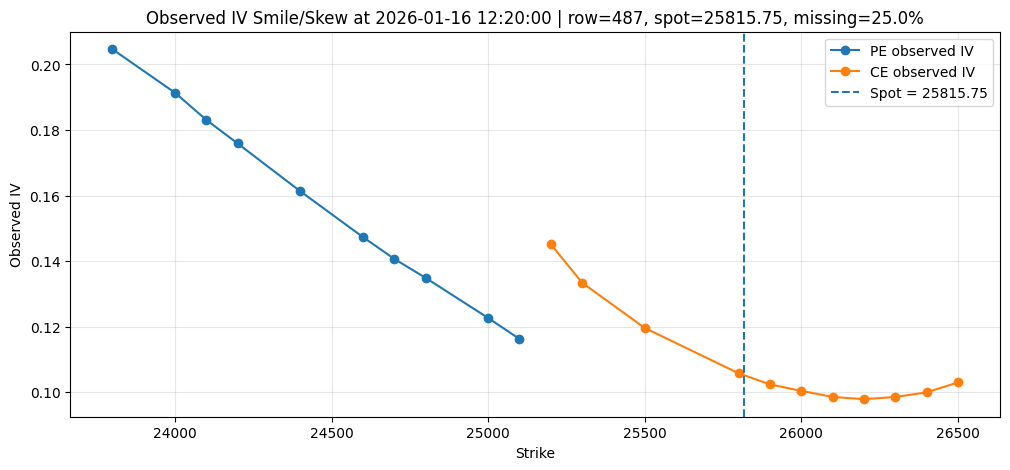

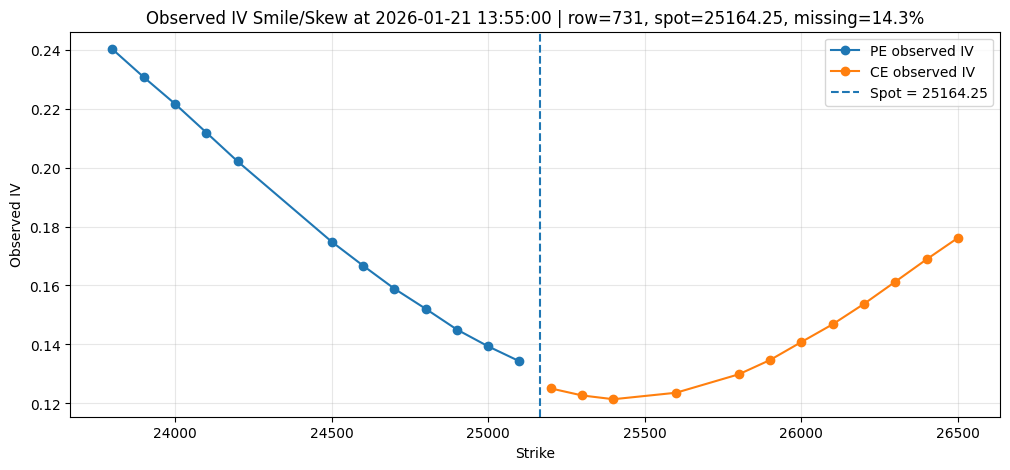

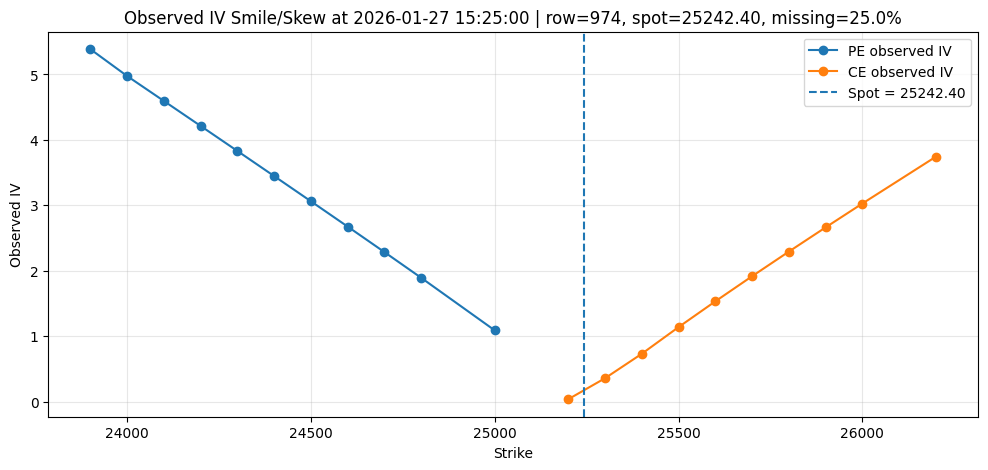

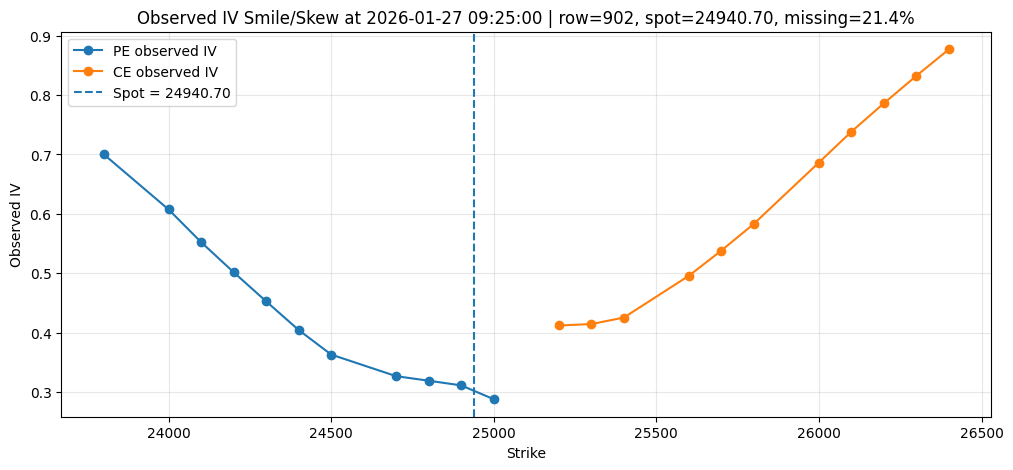

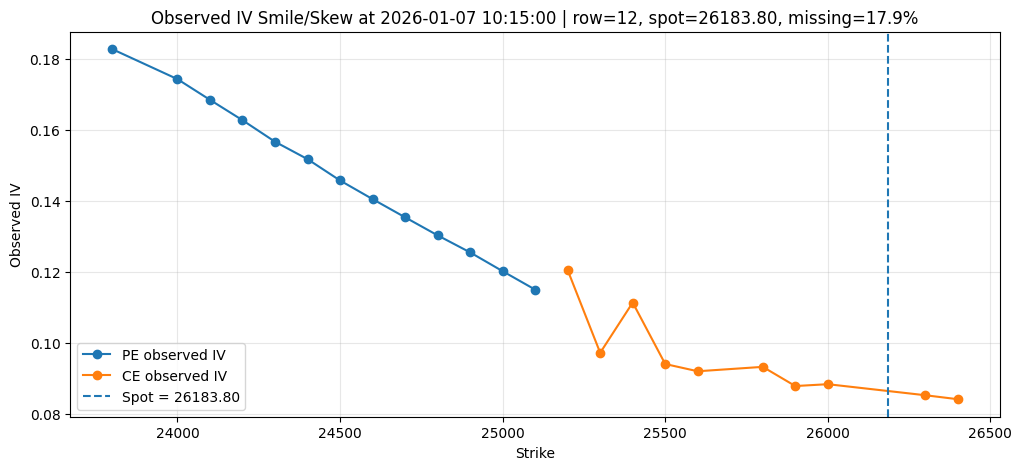

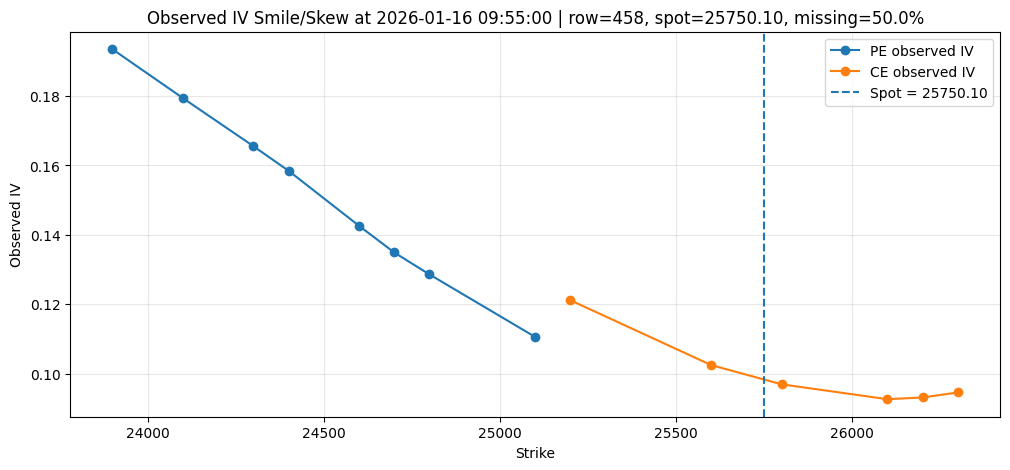

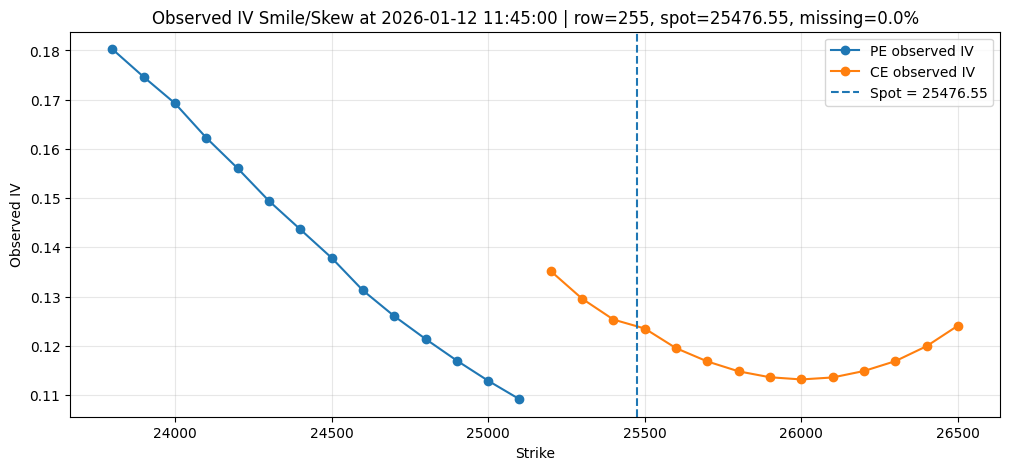

In [59]:
def plot_smile_at_row(row_idx, title_suffix=""):
    row = df.loc[row_idx]
    timestamp = row["datetime"]
    spot = row["underlying_price"]

    plt.figure(figsize=(12, 5))

    for opt_type, sub_meta in [("PE", put_meta), ("CE", call_meta)]:
        xs, ys = [], []
        for _, rec in sub_meta.iterrows():
            val = row[rec["column"]]
            if pd.notna(val):
                xs.append(rec["strike"])
                ys.append(val)
        plt.plot(xs, ys, marker="o", label=f"{opt_type} observed IV")

    plt.axvline(spot, linestyle="--", label=f"Spot = {spot:.2f}")
    plt.title(f"Observed IV Smile/Skew at {timestamp} {title_suffix}")
    plt.xlabel("Strike")
    plt.ylabel("Observed IV")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Pick representative rows
candidate_rows = [
    0,
    len(df)//4,
    len(df)//2,
    3*len(df)//4,
    len(df)-1,
    df["underlying_price"].idxmin(),
    df["underlying_price"].idxmax(),
    df["missing_rate_iv"].idxmax(),
    df["missing_rate_iv"].idxmin()
]

# Unique while preserving order
seen = set()
candidate_rows = [x for x in candidate_rows if not (x in seen or seen.add(x))]

for idx in candidate_rows:
    label = f"| row={idx}, spot={df.loc[idx, 'underlying_price']:.2f}, missing={df.loc[idx, 'missing_rate_iv']:.1%}"
    plot_smile_at_row(idx, label)

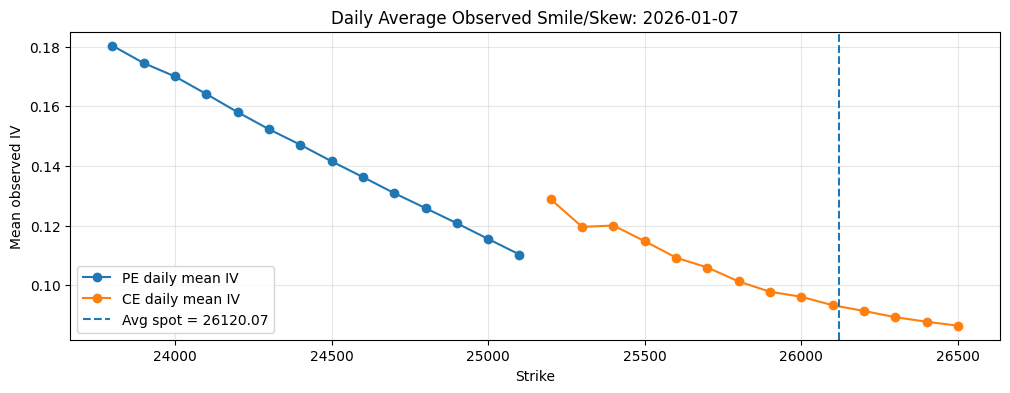

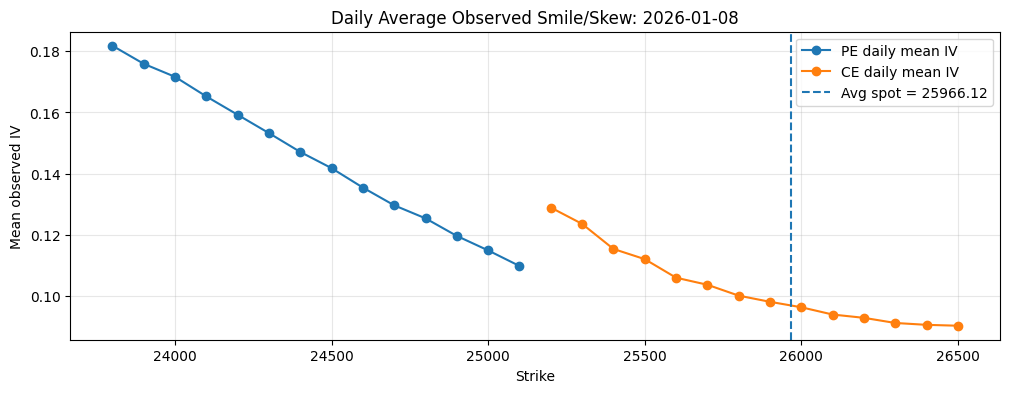

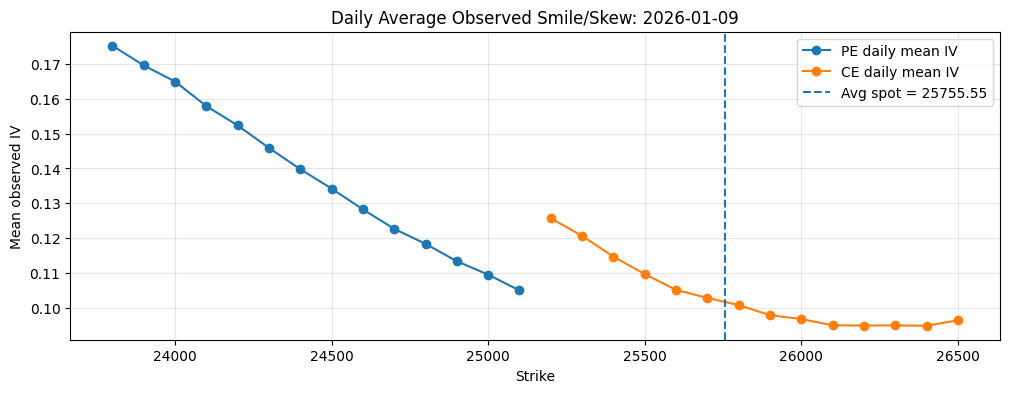

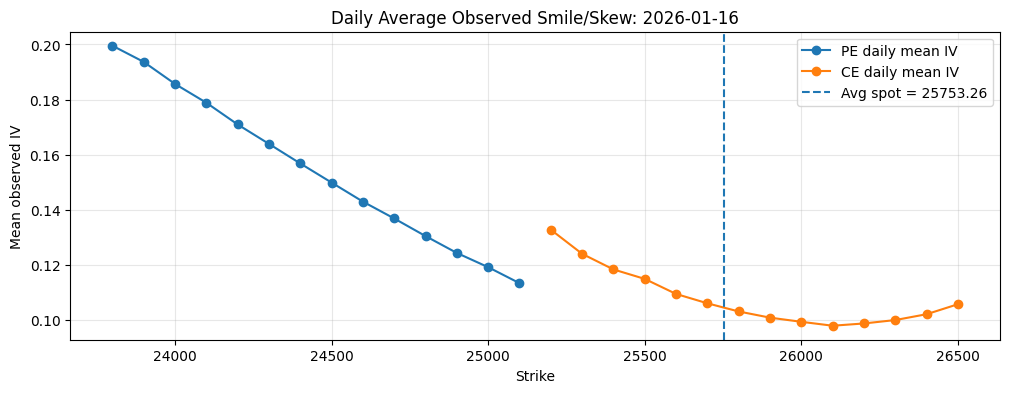

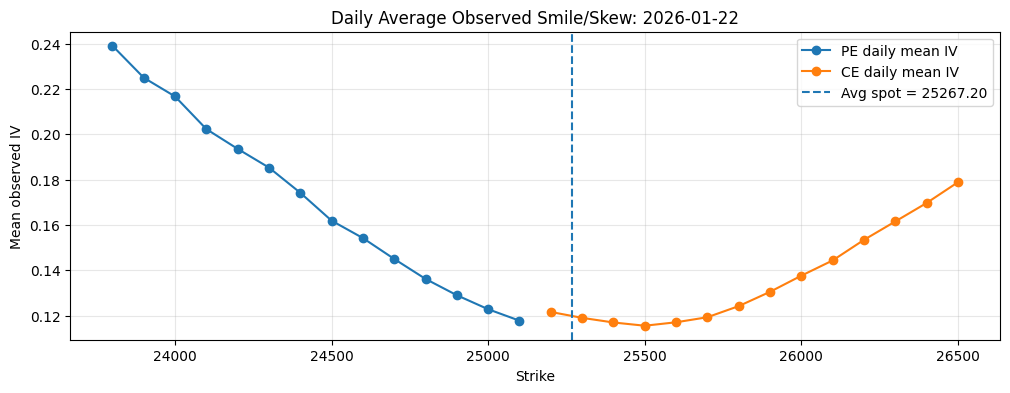

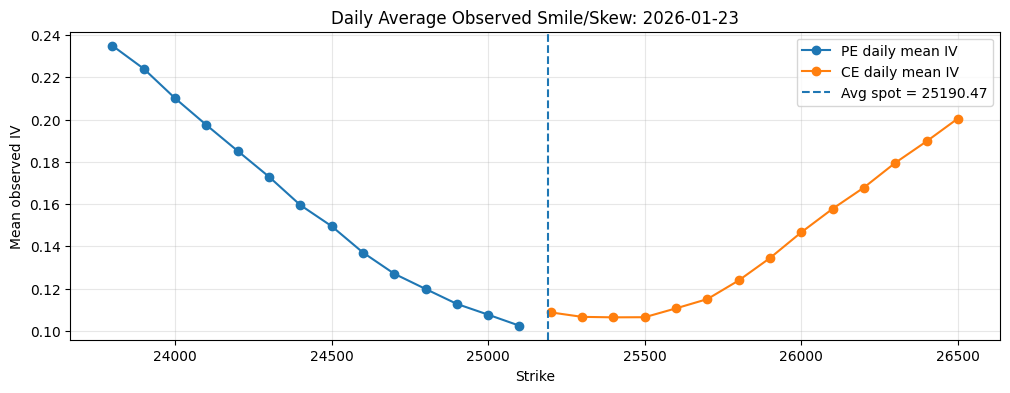

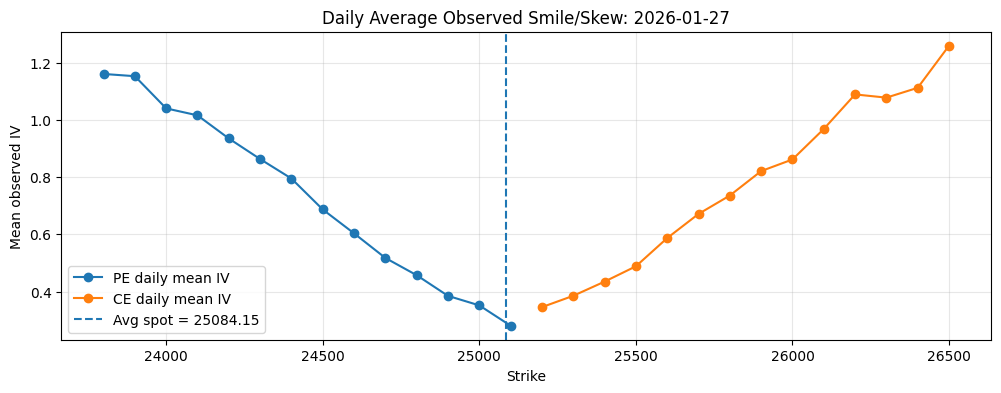

In [60]:
# Average smile by date
date_sample = sorted(df["date"].unique())
if len(date_sample) > 8:
    date_sample = [date_sample[0], date_sample[1], date_sample[2], date_sample[len(date_sample)//2], date_sample[-3], date_sample[-2], date_sample[-1]]

for d in date_sample:
    sub_df = df[df["date"] == d]
    mean_row = sub_df[option_cols].mean(skipna=True)
    avg_spot = sub_df["underlying_price"].mean()

    plt.figure(figsize=(12, 4))
    for opt_type, sub_meta in [("PE", put_meta), ("CE", call_meta)]:
        xs = sub_meta["strike"].values
        ys = [mean_row[c] for c in sub_meta["column"]]
        plt.plot(xs, ys, marker="o", label=f"{opt_type} daily mean IV")

    plt.axvline(avg_spot, linestyle="--", label=f"Avg spot = {avg_spot:.2f}")
    plt.title(f"Daily Average Observed Smile/Skew: {d}")
    plt.xlabel("Strike")
    plt.ylabel("Mean observed IV")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 9. IV heatmaps over time

This gives a compact view of the surface movie.

Rows are timestamps. Columns are option contracts.

White/blank-looking areas may be missing depending on Matplotlib rendering.

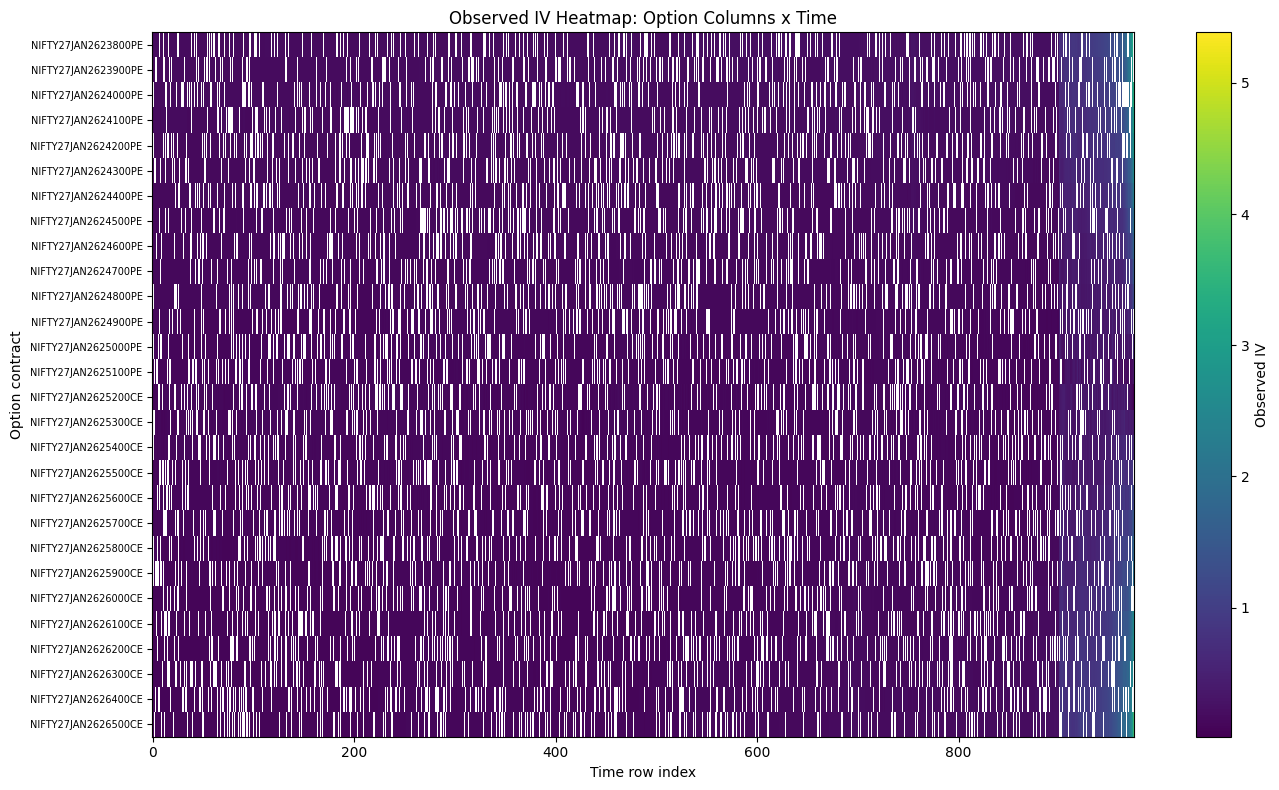

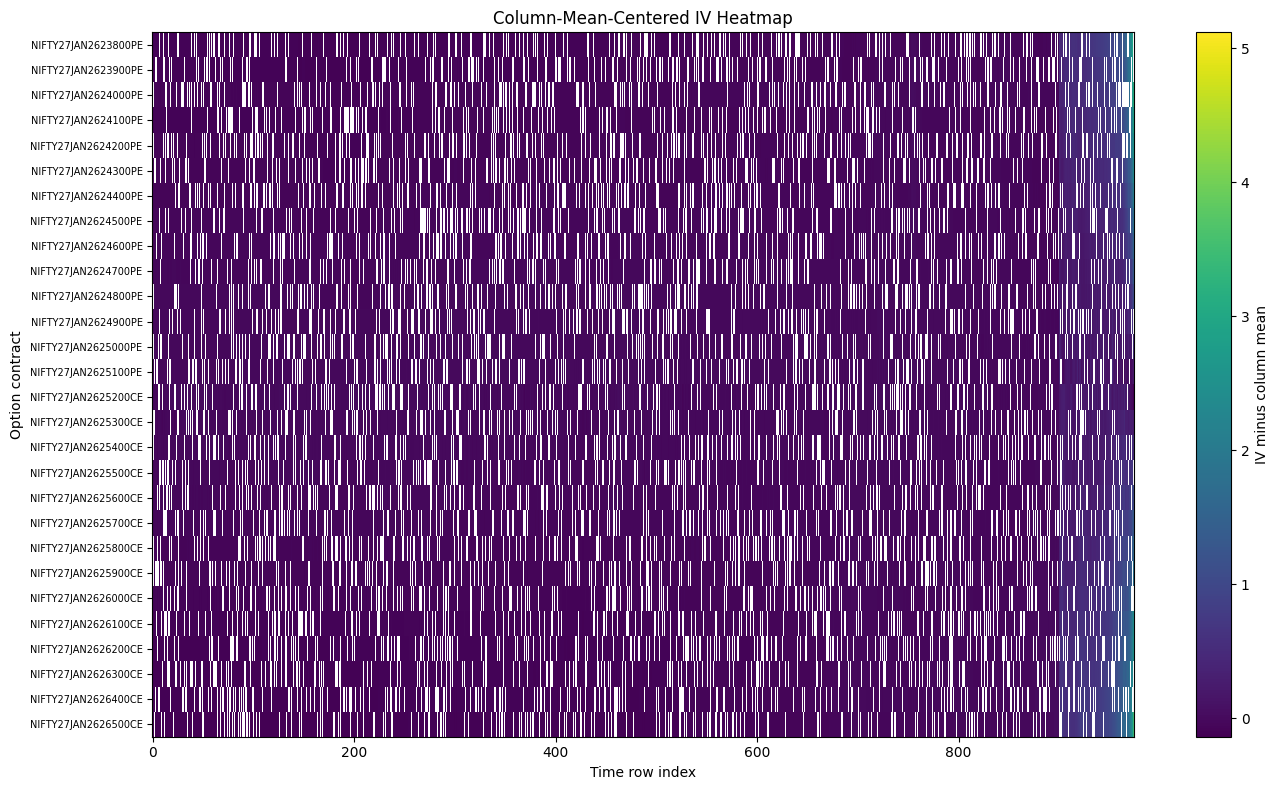

In [61]:
# Raw observed IV heatmap
iv_ordered = df[ordered_cols].copy()

plt.figure(figsize=(14, 8))
plt.imshow(iv_ordered.T, aspect="auto", interpolation="nearest")
plt.title("Observed IV Heatmap: Option Columns x Time")
plt.xlabel("Time row index")
plt.ylabel("Option contract")
plt.yticks(range(len(ordered_cols)), ordered_cols, fontsize=7)
plt.colorbar(label="Observed IV")
plt.tight_layout()
plt.show()

# Time-mean centered heatmap highlights relative movements
centered = iv_ordered - iv_ordered.mean(axis=0, skipna=True)

plt.figure(figsize=(14, 8))
plt.imshow(centered.T, aspect="auto", interpolation="nearest")
plt.title("Column-Mean-Centered IV Heatmap")
plt.xlabel("Time row index")
plt.ylabel("Option contract")
plt.yticks(range(len(ordered_cols)), ordered_cols, fontsize=7)
plt.colorbar(label="IV minus column mean")
plt.tight_layout()
plt.show()

## 10. Time dynamics of IV columns

Here we plot selected IV time series.

Useful checks:

- Do IVs move smoothly?
- Are there sudden jumps?
- Are jumps aligned across nearby strikes?
- Do edge strikes behave differently from near-ATM strikes?

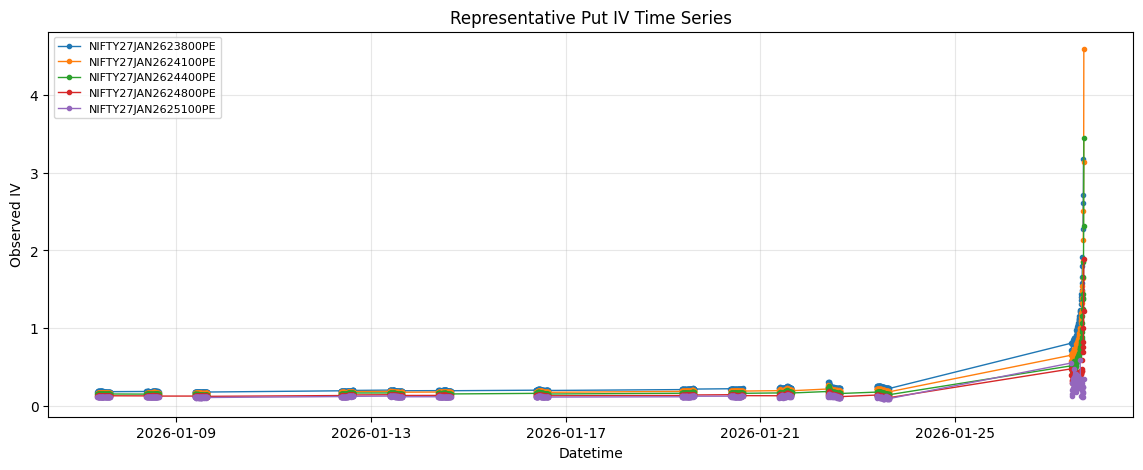

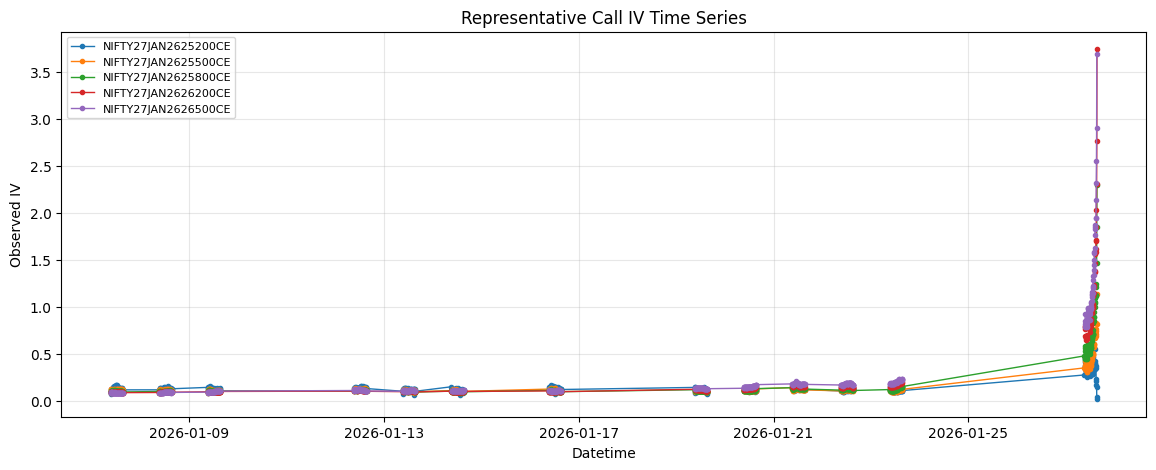

In [62]:
def choose_representative_cols(meta_sub, n=5):
    sub = meta_sub.sort_values("strike")
    if len(sub) <= n:
        return sub["column"].tolist()
    idxs = np.linspace(0, len(sub)-1, n).round().astype(int)
    return sub.iloc[idxs]["column"].tolist()

representative_puts = choose_representative_cols(put_meta, n=5)
representative_calls = choose_representative_cols(call_meta, n=5)

for title, cols in [("Representative Put IV Time Series", representative_puts),
                    ("Representative Call IV Time Series", representative_calls)]:
    plt.figure(figsize=(14, 5))
    for c in cols:
        plt.plot(df["datetime"], df[c], marker=".", linewidth=1, label=c)
    plt.title(title)
    plt.xlabel("Datetime")
    plt.ylabel("Observed IV")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.show()

,date,option_type,mean,median,std,count
0,2026-01-07,CE,0.102989,0.098770,0.015439,844
1,2026-01-07,PE,0.144427,0.143370,0.021621,869
2,2026-01-08,CE,0.103280,0.099320,0.013707,808
3,2026-01-08,PE,0.145513,0.144650,0.022772,835
4,2026-01-09,CE,0.103394,0.099705,0.011437,840
5,2026-01-09,PE,0.138507,0.136830,0.022715,849
6,2026-01-12,CE,0.117258,0.114825,0.009443,824
7,2026-01-12,PE,0.151550,0.151125,0.023861,818
8,2026-01-13,CE,0.105716,0.104800,0.007351,868
9,2026-01-13,PE,0.152463,0.151690,0.023997,808


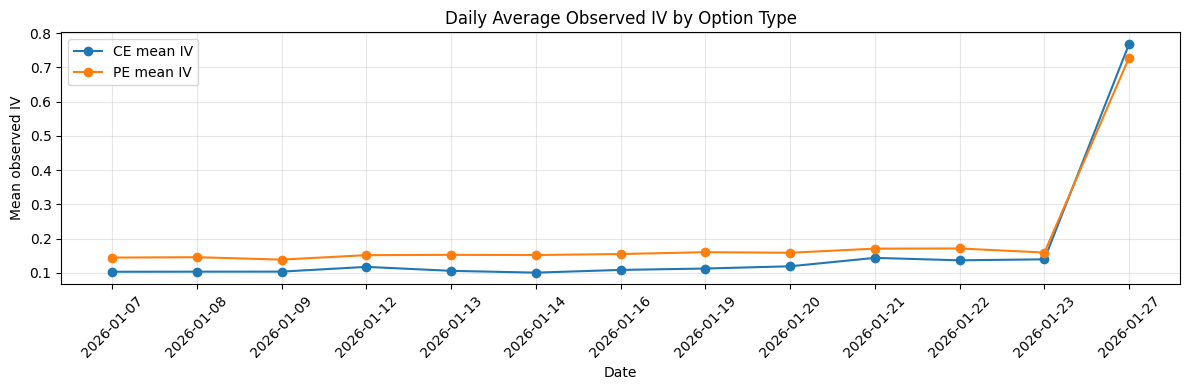

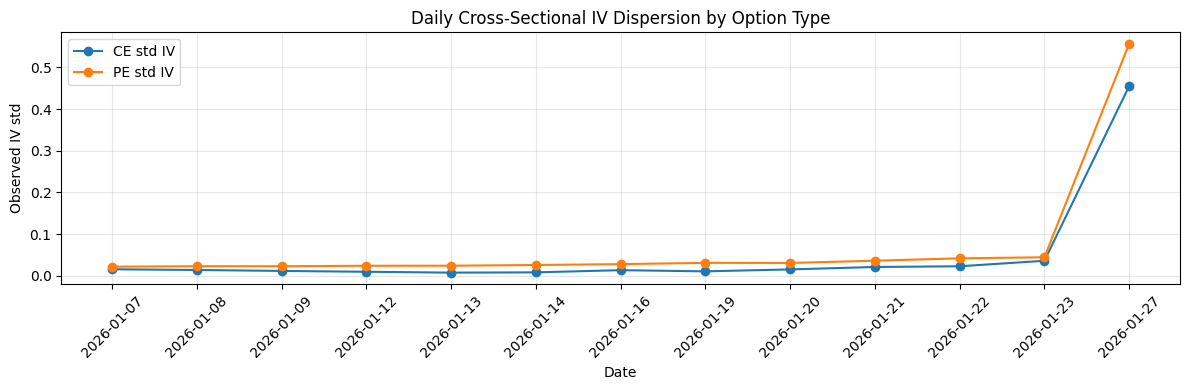

In [63]:
# Daily average IV by option type
daily_type_iv = (
    observed_long
    .groupby(["date", "option_type"])["iv"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

display(daily_type_iv)

plt.figure(figsize=(12, 4))
for opt_type, sub in daily_type_iv.groupby("option_type"):
    plt.plot(sub["date"].astype(str), sub["mean"], marker="o", label=f"{opt_type} mean IV")
plt.title("Daily Average Observed IV by Option Type")
plt.xlabel("Date")
plt.ylabel("Mean observed IV")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
for opt_type, sub in daily_type_iv.groupby("option_type"):
    plt.plot(sub["date"].astype(str), sub["std"], marker="o", label=f"{opt_type} std IV")
plt.title("Daily Cross-Sectional IV Dispersion by Option Type")
plt.xlabel("Date")
plt.ylabel("Observed IV std")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Correlation structure between option IV columns

A real IV surface usually has strong common factors:

- market-wide volatility level
- skew/smile factor
- localized strike effects
- near-expiry noise

Correlation EDA can reveal whether columns move together.

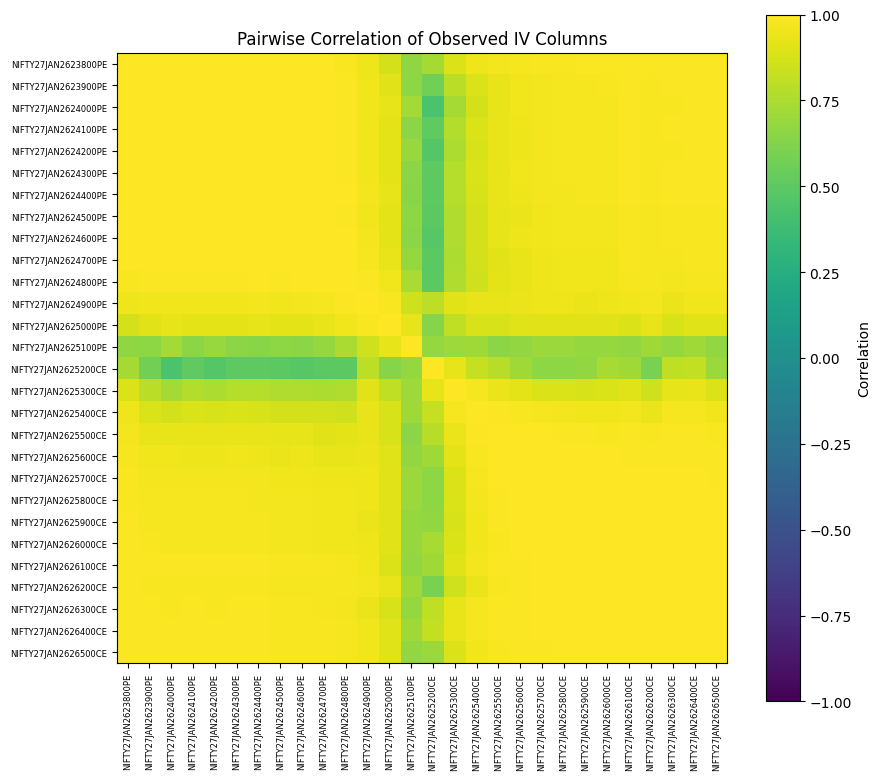

Most positively correlated pairs:


,col1,col2,corr
147,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,0.999851
125,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,0.999831
377,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,0.999819
0,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,0.999814
54,NIFTY27JAN2624000PE,NIFTY27JAN2624200PE,0.999796
28,NIFTY27JAN2623900PE,NIFTY27JAN2624100PE,0.999748
363,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,0.999742
27,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,0.999726
53,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,0.999722
102,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,0.999720


Least correlated pairs:


,col1,col2,corr
64,NIFTY27JAN2624000PE,NIFTY27JAN2625200CE,0.435174
111,NIFTY27JAN2624200PE,NIFTY27JAN2625200CE,0.472267
193,NIFTY27JAN2624600PE,NIFTY27JAN2625200CE,0.477667
228,NIFTY27JAN2624800PE,NIFTY27JAN2625200CE,0.494070
211,NIFTY27JAN2624700PE,NIFTY27JAN2625200CE,0.495887
174,NIFTY27JAN2624500PE,NIFTY27JAN2625200CE,0.497382
133,NIFTY27JAN2624300PE,NIFTY27JAN2625200CE,0.503600
154,NIFTY27JAN2624400PE,NIFTY27JAN2625200CE,0.507366
88,NIFTY27JAN2624100PE,NIFTY27JAN2625200CE,0.509570
39,NIFTY27JAN2623900PE,NIFTY27JAN2625200CE,0.575308


In [64]:
corr = df[ordered_cols].corr(min_periods=100)

plt.figure(figsize=(9, 8))
plt.imshow(corr, interpolation="nearest", vmin=-1, vmax=1)
plt.title("Pairwise Correlation of Observed IV Columns")
plt.xticks(range(len(ordered_cols)), ordered_cols, rotation=90, fontsize=6)
plt.yticks(range(len(ordered_cols)), ordered_cols, fontsize=6)
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

# Show most and least correlated pairs
pairs = []
for i in range(len(ordered_cols)):
    for j in range(i+1, len(ordered_cols)):
        pairs.append((ordered_cols[i], ordered_cols[j], corr.iloc[i, j]))
corr_pairs = pd.DataFrame(pairs, columns=["col1", "col2", "corr"]).dropna()

print("Most positively correlated pairs:")
display(corr_pairs.sort_values("corr", ascending=False).head(15))

print("Least correlated pairs:")
display(corr_pairs.sort_values("corr", ascending=True).head(15))

## 12. Relationship between IV and underlying price

This checks whether IV level/skew changes when the underlying moves.

Common equity-index behavior:

- spot down can coincide with higher IV
- downside put IVs may rise more strongly
- skew may steepen during stress moves

This is descriptive only.

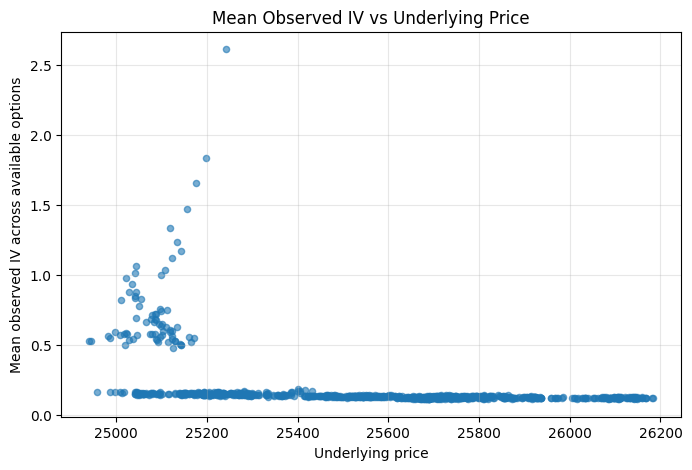

Correlation between underlying_price and mean_observed_iv:
                    underlying_price  mean_observed_iv  median_observed_iv  missing_rate_iv
underlying_price            1.000000         -0.412927           -0.406231         0.024433
mean_observed_iv           -0.412927          1.000000            0.998281        -0.004812
median_observed_iv         -0.406231          0.998281            1.000000        -0.005523
missing_rate_iv             0.024433         -0.004812           -0.005523         1.000000


In [65]:
# Average observed IV per timestamp
df["mean_observed_iv"] = df[option_cols].mean(axis=1, skipna=True)
df["median_observed_iv"] = df[option_cols].median(axis=1, skipna=True)

plt.figure(figsize=(8, 5))
plt.scatter(df["underlying_price"], df["mean_observed_iv"], s=20, alpha=0.6)
plt.title("Mean Observed IV vs Underlying Price")
plt.xlabel("Underlying price")
plt.ylabel("Mean observed IV across available options")
plt.grid(True, alpha=0.3)
plt.show()

print("Correlation between underlying_price and mean_observed_iv:")
print(df[["underlying_price", "mean_observed_iv", "median_observed_iv", "missing_rate_iv"]].corr())

,column,corr_with_underlying,strike,option_type
0,NIFTY27JAN2625200CE,-0.380080,25200,CE
1,NIFTY27JAN2625300CE,-0.410604,25300,CE
2,NIFTY27JAN2625400CE,-0.407924,25400,CE
3,NIFTY27JAN2625500CE,-0.403640,25500,CE
4,NIFTY27JAN2625600CE,-0.403506,25600,CE
5,NIFTY27JAN2625700CE,-0.408311,25700,CE
6,NIFTY27JAN2625800CE,-0.427807,25800,CE
7,NIFTY27JAN2625900CE,-0.434655,25900,CE
8,NIFTY27JAN2626000CE,-0.440383,26000,CE
9,NIFTY27JAN2626100CE,-0.464214,26100,CE


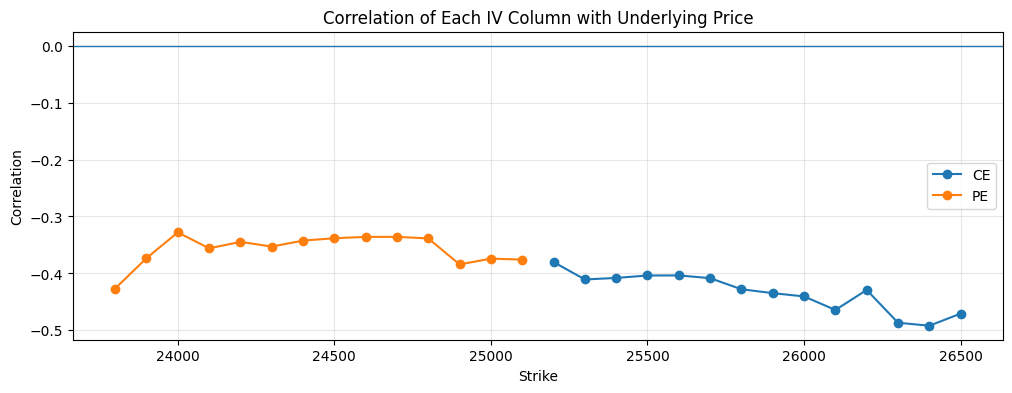

In [66]:
# Column-wise correlation with underlying price
underlying_corr = []
for c in option_cols:
    valid = df[["underlying_price", c]].dropna()
    if len(valid) >= 30:
        underlying_corr.append({
            "column": c,
            "corr_with_underlying": valid["underlying_price"].corr(valid[c])
        })

underlying_corr = pd.DataFrame(underlying_corr).merge(meta[["column", "strike", "option_type"]], on="column")
underlying_corr = underlying_corr.sort_values(["option_type", "strike"])

display(underlying_corr)

plt.figure(figsize=(12, 4))
for opt_type, sub in underlying_corr.groupby("option_type"):
    plt.plot(sub["strike"], sub["corr_with_underlying"], marker="o", label=opt_type)
plt.axhline(0, linewidth=1)
plt.title("Correlation of Each IV Column with Underlying Price")
plt.xlabel("Strike")
plt.ylabel("Correlation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 13. Surface smoothness diagnostics

A realistic IV surface should not be extremely jagged across neighboring strikes.

Here we compute simple cross-strike differences using only adjacent observed values.

For each timestamp and option type:

```text
first difference = IV(K_{i+1}) - IV(K_i)
second difference = IV(K_{i+1}) - 2 IV(K_i) + IV(K_{i-1})
```

Large absolute values may indicate noise, missingness artifacts, or genuinely unstable regions.

count      mean       std      min      25%      50%      75%      max
option_type metric                                                                              
CE          first_diff   9984.0  0.007440  0.034228 -0.06357 -0.00251  0.00021  0.00578  0.92911
            second_diff  9009.0  0.001460  0.023623 -0.66470 -0.00026  0.00091  0.00227  0.82316
PE          first_diff   9906.0 -0.014889  0.032984 -0.80280 -0.01113 -0.00726 -0.00567  0.06151
            second_diff  8931.0  0.000617  0.019858 -0.40987 -0.00107  0.00030  0.00159  0.56652

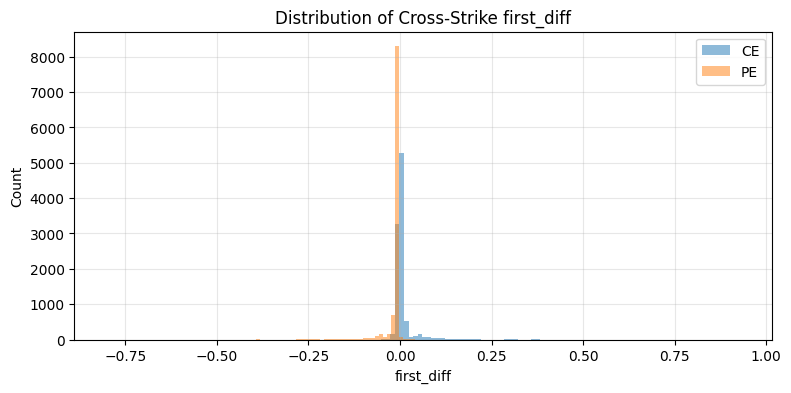

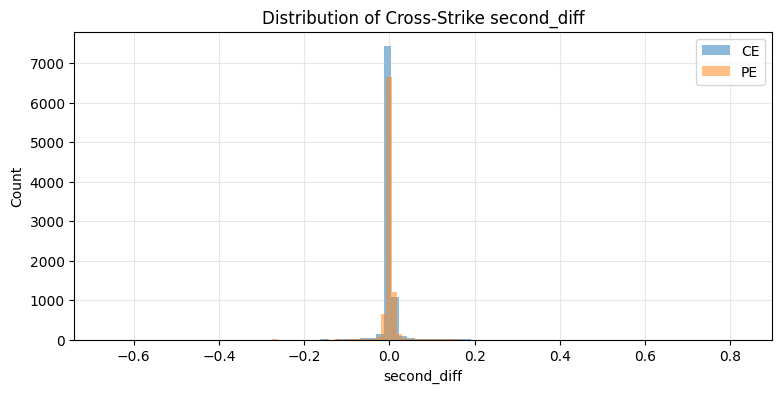

In [67]:
smooth_records = []

for row_idx, row in df.iterrows():
    for opt_type, sub_meta in [("PE", put_meta), ("CE", call_meta)]:
        sub_meta = sub_meta.sort_values("strike")
        vals = []
        strikes_local = []
        for _, rec in sub_meta.iterrows():
            val = row[rec["column"]]
            if pd.notna(val):
                vals.append(val)
                strikes_local.append(rec["strike"])

        vals = np.array(vals, dtype=float)
        strikes_local = np.array(strikes_local, dtype=float)

        # Adjacent differences only where neighboring strikes are actually adjacent in the available subset.
        if len(vals) >= 2:
            d1 = np.diff(vals)
            smooth_records.extend([
                {
                    "datetime": row["datetime"],
                    "option_type": opt_type,
                    "metric": "first_diff",
                    "value": x
                }
                for x in d1
            ])
        if len(vals) >= 3:
            d2 = vals[2:] - 2 * vals[1:-1] + vals[:-2]
            smooth_records.extend([
                {
                    "datetime": row["datetime"],
                    "option_type": opt_type,
                    "metric": "second_diff",
                    "value": x
                }
                for x in d2
            ])

smooth_df = pd.DataFrame(smooth_records)

display(smooth_df.groupby(["option_type", "metric"])["value"].describe())

for metric in ["first_diff", "second_diff"]:
    plt.figure(figsize=(9, 4))
    for opt_type, sub in smooth_df[smooth_df["metric"] == metric].groupby("option_type"):
        sub["value"].plot(kind="hist", bins=80, alpha=0.5, label=opt_type)
    plt.title(f"Distribution of Cross-Strike {metric}")
    plt.xlabel(metric)
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 14. Static no-arbitrage diagnostics on observed data

No-static-arbitrage conditions are constraints on **option prices**, not directly on IV.

To diagnose the observed IV surface, we approximately convert observed IVs to Black-Scholes prices using:

- spot = `underlying_price`
- strike = parsed strike
- time to expiry = `years_to_expiry`
- volatility = observed IV
- risk-free rate = configurable
- dividend yield = configurable

Then we check simple same-expiry, same-type strike conditions:

### Calls

1. Call price should decrease as strike increases.
2. Call price should be convex in strike.

### Puts

1. Put price should increase as strike increases.
2. Put price should be convex in strike.

Caveats:

- This is only a diagnostic.
- Real NIFTY options may require more precise rates/dividends/forwards.
- Near-expiry numerical behavior can be noisy.
- We only test where enough observed strikes exist.
- Call/put parity is not directly testable here if calls and puts do not share matching strikes.

In [68]:
from math import erf, sqrt, exp, log

RISK_FREE_RATE = 0.00
DIVIDEND_YIELD = 0.00
MIN_T = 1e-6

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price(S, K, T, sigma, option_type, r=RISK_FREE_RATE, q=DIVIDEND_YIELD):
    if pd.isna(sigma) or sigma <= 0 or pd.isna(S) or pd.isna(K):
        return np.nan
    T = max(float(T), MIN_T)
    sigma = max(float(sigma), 1e-8)
    d1 = (log(S / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    if option_type == "CE":
        return S * exp(-q * T) * norm_cdf(d1) - K * exp(-r * T) * norm_cdf(d2)
    elif option_type == "PE":
        return K * exp(-r * T) * norm_cdf(-d2) - S * exp(-q * T) * norm_cdf(-d1)
    return np.nan

arb_records = []

for row_idx, row in df.iterrows():
    S = row["underlying_price"]
    T = row["years_to_expiry"]

    for opt_type, sub_meta in [("CE", call_meta), ("PE", put_meta)]:
        sub_meta = sub_meta.sort_values("strike")

        prices = []
        strikes_local = []
        used_cols = []

        for _, rec in sub_meta.iterrows():
            iv_val = row[rec["column"]]
            if pd.notna(iv_val):
                price = bs_price(S, rec["strike"], T, iv_val, opt_type)
                if pd.notna(price):
                    prices.append(price)
                    strikes_local.append(rec["strike"])
                    used_cols.append(rec["column"])

        prices = np.array(prices, dtype=float)
        strikes_local = np.array(strikes_local, dtype=float)

        if len(prices) >= 2:
            price_diffs = np.diff(prices)
            if opt_type == "CE":
                monotonic_violations = np.sum(price_diffs > 1e-8)
            else:
                monotonic_violations = np.sum(price_diffs < -1e-8)
        else:
            monotonic_violations = np.nan

        if len(prices) >= 3:
            second_diff = prices[2:] - 2 * prices[1:-1] + prices[:-2]
            convexity_violations = np.sum(second_diff < -1e-8)
            min_second_diff = np.min(second_diff)
        else:
            convexity_violations = np.nan
            min_second_diff = np.nan

        arb_records.append({
            "datetime": row["datetime"],
            "date": row["date"],
            "option_type": opt_type,
            "num_observed_prices": len(prices),
            "monotonic_violations": monotonic_violations,
            "convexity_violations": convexity_violations,
            "min_second_diff": min_second_diff
        })

arb_diag = pd.DataFrame(arb_records)

display(arb_diag.head())

summary_arb = arb_diag.groupby("option_type").agg(
    rows=("datetime", "count"),
    avg_observed_prices=("num_observed_prices", "mean"),
    total_monotonic_violations=("monotonic_violations", "sum"),
    total_convexity_violations=("convexity_violations", "sum"),
    avg_monotonic_violations=("monotonic_violations", "mean"),
    avg_convexity_violations=("convexity_violations", "mean"),
    min_second_diff=("min_second_diff", "min")
)

display(summary_arb)

,datetime,date,option_type,num_observed_prices,monotonic_violations,convexity_violations,min_second_diff
0,2026-01-07 09:15:00,2026-01-07,CE,12,0,3,-80.769949
1,2026-01-07 09:15:00,2026-01-07,PE,13,0,3,-0.156747
2,2026-01-07 09:20:00,2026-01-07,CE,10,0,1,-147.474734
3,2026-01-07 09:20:00,2026-01-07,PE,10,0,3,-0.712428
4,2026-01-07 09:25:00,2026-01-07,CE,12,0,1,-5.805724


,rows,avg_observed_prices,total_monotonic_violations,total_convexity_violations,avg_monotonic_violations,avg_convexity_violations,min_second_diff
option_type,,,,,,,
CE,975,11.24,0,1367,0.000000,1.402051,-276.988919
PE,975,11.16,46,2110,0.047179,2.164103,-25.008052


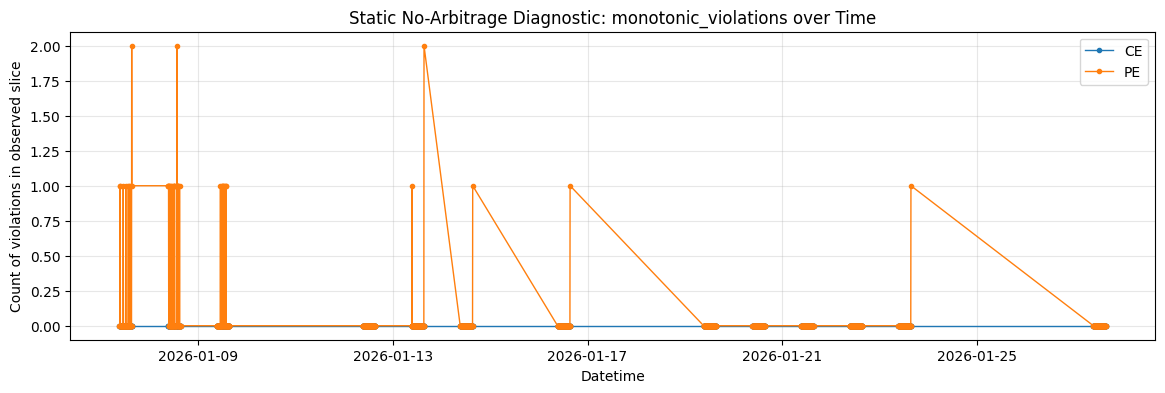

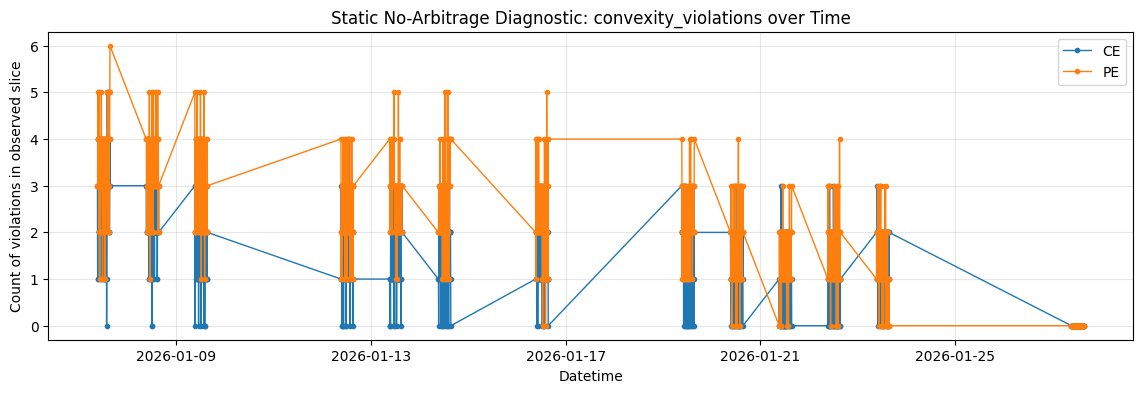

Rows with largest total diagnostic violations:


,datetime,date,option_type,num_observed_prices,monotonic_violations,convexity_violations,min_second_diff,total_violations
147,2026-01-07 15:20:00,2026-01-07,PE,13,2,5,-0.651467,7
149,2026-01-07 15:25:00,2026-01-07,PE,13,1,6,-1.152525,7
47,2026-01-07 11:10:00,2026-01-07,PE,12,1,5,-1.424802,6
407,2026-01-09 13:40:00,2026-01-09,PE,11,1,5,-1.707045,6
273,2026-01-08 14:20:00,2026-01-08,PE,12,1,5,-1.121688,6
221,2026-01-08 12:10:00,2026-01-08,PE,12,1,5,-1.693547,6
287,2026-01-08 14:55:00,2026-01-08,PE,14,1,5,-0.798688,6
225,2026-01-08 12:20:00,2026-01-08,PE,13,1,4,-2.311112,5
135,2026-01-07 14:50:00,2026-01-07,PE,12,0,5,-0.826533,5
651,2026-01-13 11:20:00,2026-01-13,PE,13,0,5,-2.638602,5


In [69]:
# Plot arbitrage diagnostic violations over time
for metric in ["monotonic_violations", "convexity_violations"]:
    plt.figure(figsize=(14, 4))
    for opt_type, sub in arb_diag.groupby("option_type"):
        plt.plot(sub["datetime"], sub[metric], marker=".", linewidth=1, label=opt_type)
    plt.title(f"Static No-Arbitrage Diagnostic: {metric} over Time")
    plt.xlabel("Datetime")
    plt.ylabel("Count of violations in observed slice")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Most suspicious rows
print("Rows with largest total diagnostic violations:")
arb_diag["total_violations"] = arb_diag[["monotonic_violations", "convexity_violations"]].sum(axis=1)
display(arb_diag.sort_values("total_violations", ascending=False).head(20))

## 15. Missingness mechanism: does missingness depend on observable features?

This matters because if missingness is structured, naive imputation can be biased.

We test relationships between missingness and:

- underlying price
- time to expiry
- option type
- strike
- moneyness
- time of day

,option_type,strike,missing_rate,total_cells,mean_log_moneyness,mean_abs_log_moneyness
0,CE,25200,0.198974,975,-0.014270,0.015660
1,CE,25300,0.188718,975,-0.010310,0.013578
2,CE,25400,0.207179,975,-0.006365,0.012061
3,CE,25500,0.185641,975,-0.002436,0.010920
4,CE,25600,0.184615,975,0.001478,0.010448
5,CE,25700,0.206154,975,0.005377,0.010673
6,CE,25800,0.215385,975,0.009260,0.012317
7,CE,25900,0.186667,975,0.013129,0.014835
8,CE,26000,0.185641,975,0.016982,0.017793
9,CE,26100,0.187692,975,0.020821,0.020962


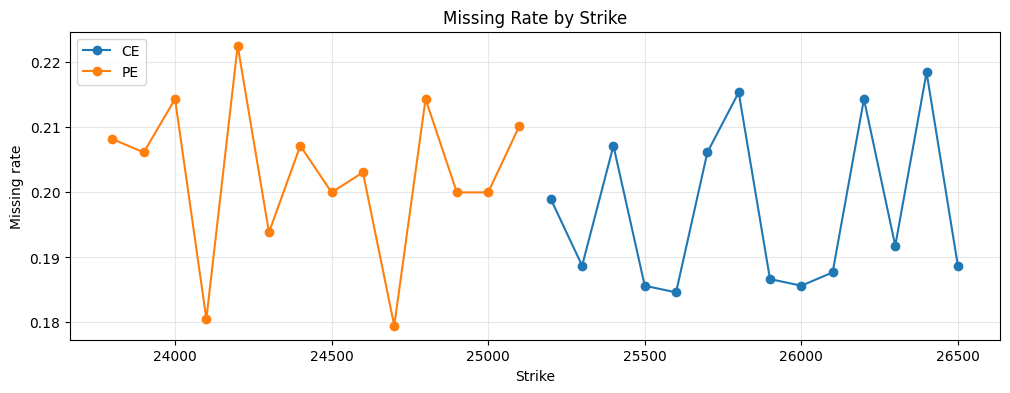

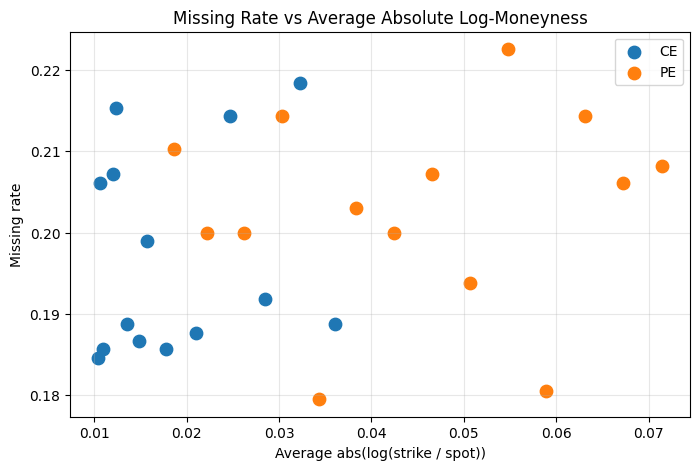

In [70]:
# Long missingness summary
miss_long_summary = long.groupby(["option_type", "strike"]).agg(
    missing_rate=("is_missing", "mean"),
    total_cells=("is_missing", "size"),
    mean_log_moneyness=("log_moneyness", "mean"),
    mean_abs_log_moneyness=("abs_log_moneyness", "mean")
).reset_index()

display(miss_long_summary)

plt.figure(figsize=(12, 4))
for opt_type, sub in miss_long_summary.groupby("option_type"):
    plt.plot(sub["strike"], sub["missing_rate"], marker="o", label=opt_type)
plt.title("Missing Rate by Strike")
plt.xlabel("Strike")
plt.ylabel("Missing rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for opt_type, sub in miss_long_summary.groupby("option_type"):
    plt.scatter(sub["mean_abs_log_moneyness"], sub["missing_rate"], s=80, label=opt_type)
plt.title("Missing Rate vs Average Absolute Log-Moneyness")
plt.xlabel("Average abs(log(strike / spot))")
plt.ylabel("Missing rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

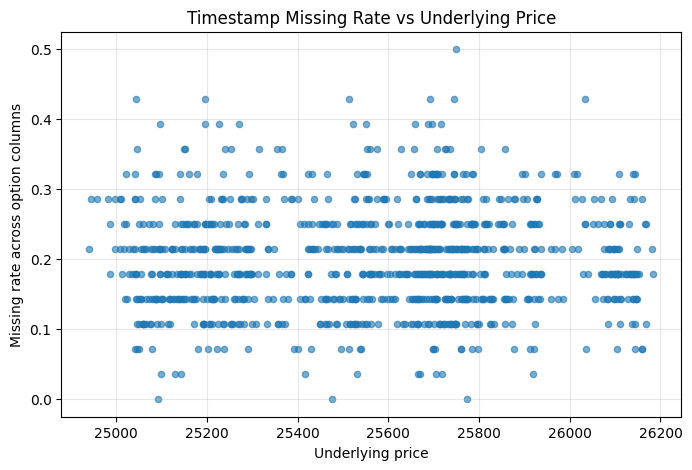

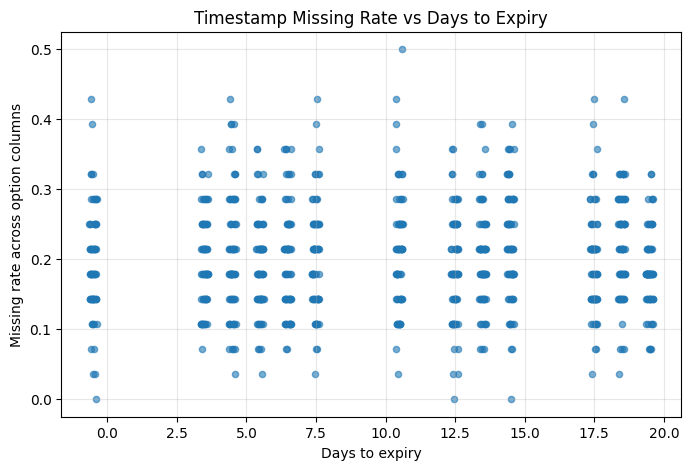

,underlying_price,days_to_expiry,missing_rate_iv
underlying_price,1.000000,0.920886,0.024433
days_to_expiry,0.920886,1.000000,0.023960
missing_rate_iv,0.024433,0.023960,1.000000


In [71]:
# Row-level missingness vs underlying/time-to-expiry
fig_data = df[["datetime", "underlying_price", "days_to_expiry", "missing_rate_iv"]].copy()

plt.figure(figsize=(8, 5))
plt.scatter(fig_data["underlying_price"], fig_data["missing_rate_iv"], s=20, alpha=0.6)
plt.title("Timestamp Missing Rate vs Underlying Price")
plt.xlabel("Underlying price")
plt.ylabel("Missing rate across option columns")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(fig_data["days_to_expiry"], fig_data["missing_rate_iv"], s=20, alpha=0.6)
plt.title("Timestamp Missing Rate vs Days to Expiry")
plt.xlabel("Days to expiry")
plt.ylabel("Missing rate across option columns")
plt.grid(True, alpha=0.3)
plt.show()

display(fig_data[["underlying_price", "days_to_expiry", "missing_rate_iv"]].corr())

## 16. Outlier and suspicious-value scan

This section does not remove anything.

It only flags:

- very high IV observations
- very low IV observations
- large one-step IV jumps within a column
- rows with unusually high cross-sectional IV dispersion

These are useful to inspect before deciding whether robust smoothing is needed later.

In [72]:
# Extreme IV observations
q_low = observed_iv_values.quantile(0.01)
q_high = observed_iv_values.quantile(0.99)

print("1% IV quantile:", q_low)
print("99% IV quantile:", q_high)

extreme_records = observed_long[(observed_long["iv"] <= q_low) | (observed_long["iv"] >= q_high)].copy()
extreme_records["extreme_type"] = np.where(extreme_records["iv"] <= q_low, "low", "high")

display(
    extreme_records
    .sort_values(["extreme_type", "iv"])
    [["datetime", "underlying_price", "column", "strike", "option_type", "iv", "moneyness", "days_to_expiry", "extreme_type"]]
    .head(50)
)

display(
    extreme_records
    .sort_values(["extreme_type", "iv"], ascending=[True, False])
    [["datetime", "underlying_price", "column", "strike", "option_type", "iv", "moneyness", "days_to_expiry", "extreme_type"]]
    .tail(50)
)

1% IV quantile: 0.0878756
99% IV quantile: 1.1381130000000015


,datetime,underlying_price,column,strike,option_type,iv,moneyness,days_to_expiry,extreme_type
13621,2026-01-27 13:05:00,25077.30,NIFTY27JAN2626500CE,26500,CE,1.13901,1.056733,-0.545139,high
3899,2026-01-27 15:25:00,25242.40,NIFTY27JAN2625500CE,25500,CE,1.13908,1.010205,-0.642361,high
17534,2026-01-27 14:10:00,25041.35,NIFTY27JAN2624100PE,24100,PE,1.14421,0.962408,-0.590278,high
13623,2026-01-27 13:15:00,25088.55,NIFTY27JAN2626500CE,26500,CE,1.14869,1.056259,-0.552083,high
9732,2026-01-27 14:00:00,25042.35,NIFTY27JAN2626100CE,26100,CE,1.15066,1.042234,-0.583333,high
16555,2026-01-27 13:50:00,25054.30,NIFTY27JAN2624000PE,24000,PE,1.15066,0.957919,-0.576389,high
10704,2026-01-27 13:45:00,25044.10,NIFTY27JAN2626200CE,26200,CE,1.15186,1.046155,-0.572917,high
20466,2026-01-27 14:45:00,25108.10,NIFTY27JAN2624400PE,24400,PE,1.15422,0.971798,-0.614583,high
12649,2026-01-27 13:20:00,25085.90,NIFTY27JAN2626400CE,26400,CE,1.15693,1.052384,-0.555556,high
14598,2026-01-27 13:15:00,25088.55,NIFTY27JAN2623800PE,23800,PE,1.15813,0.948640,-0.552083,high


,datetime,underlying_price,column,strike,option_type,iv,moneyness,days_to_expiry,extreme_type
12748,2026-01-07 15:20:00,26138.30,NIFTY27JAN2626500CE,26500,CE,0.08402,1.013838,19.361111,low
11851,2026-01-09 09:20:00,25916.20,NIFTY27JAN2626400CE,26400,CE,0.08400,1.018668,17.611111,low
12738,2026-01-07 14:30:00,26098.65,NIFTY27JAN2626500CE,26500,CE,0.08388,1.015378,19.395833,low
8780,2026-01-07 09:40:00,26145.15,NIFTY27JAN2626100CE,26100,CE,0.08386,0.998273,19.597222,low
12758,2026-01-08 09:55:00,26089.40,NIFTY27JAN2626500CE,26500,CE,0.08383,1.015738,18.586806,low
11785,2026-01-08 10:05:00,26068.05,NIFTY27JAN2626400CE,26400,CE,0.08374,1.012734,18.579861,low
27217,2026-01-23 14:50:00,25059.30,NIFTY27JAN2625100PE,25100,PE,0.08374,1.001624,3.381944,low
12741,2026-01-07 14:45:00,26107.25,NIFTY27JAN2626500CE,26500,CE,0.08370,1.015044,19.385417,low
9826,2026-01-08 09:20:00,26109.70,NIFTY27JAN2626200CE,26200,CE,0.08368,1.003458,18.611111,low
10797,2026-01-07 15:15:00,26147.80,NIFTY27JAN2626300CE,26300,CE,0.08366,1.005821,19.364583,low


,datetime,column,strike,option_type,prev_iv,iv,diff,abs_diff,threshold_99pct_for_column
115,2026-01-27 15:25:00,NIFTY27JAN2624000PE,24000,PE,3.40433,4.97453,1.57020,1.57020,0.047950
122,2026-01-27 15:25:00,NIFTY27JAN2624100PE,24100,PE,3.13418,4.59339,1.45921,1.45921,0.092567
128,2026-01-27 15:25:00,NIFTY27JAN2624200PE,24200,PE,2.86358,4.21172,1.34814,1.34814,0.058918
135,2026-01-27 15:25:00,NIFTY27JAN2624300PE,24300,PE,2.59234,3.82927,1.23693,1.23693,0.119382
142,2026-01-27 15:25:00,NIFTY27JAN2624400PE,24400,PE,2.32024,3.44575,1.12551,1.12551,0.093333
149,2026-01-27 15:25:00,NIFTY27JAN2624500PE,24500,PE,2.04698,3.06078,1.01380,1.01380,0.067219
74,2026-01-27 15:25:00,NIFTY27JAN2626200CE,26200,CE,2.76165,3.74259,0.98094,0.98094,0.085034
156,2026-01-27 15:25:00,NIFTY27JAN2624600PE,24600,PE,1.77218,2.67390,0.90172,0.90172,0.095197
163,2026-01-27 15:25:00,NIFTY27JAN2624700PE,24700,PE,1.49530,2.28444,0.78914,0.78914,0.081020
94,2026-01-27 15:20:00,NIFTY27JAN2626500CE,26500,CE,2.90515,3.69076,0.78561,0.78561,0.073869


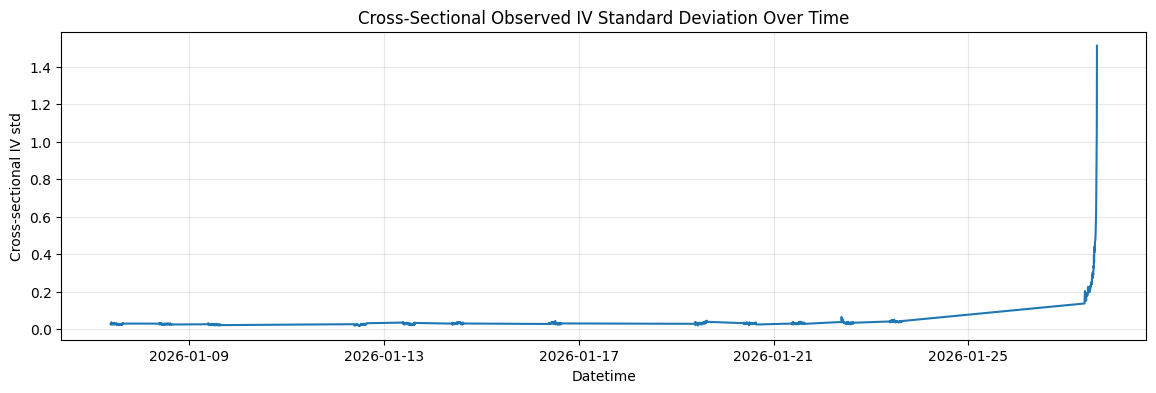

,datetime,underlying_price,missing_rate_iv,cross_sectional_iv_std,cross_sectional_iv_range
974,2026-01-27 15:25:00,25242.40,0.250000,1.511662,5.34750
973,2026-01-27 15:20:00,25198.10,0.250000,1.056271,3.67396
972,2026-01-27 15:15:00,25174.85,0.142857,0.922546,3.02976
971,2026-01-27 15:10:00,25154.95,0.250000,0.799502,2.54326
970,2026-01-27 15:05:00,25134.65,0.178571,0.724432,2.49272
969,2026-01-27 15:00:00,25118.00,0.142857,0.623317,2.04914
968,2026-01-27 14:55:00,25143.55,0.214286,0.575812,1.82077
967,2026-01-27 14:50:00,25122.30,0.214286,0.548297,1.78038
966,2026-01-27 14:45:00,25108.10,0.214286,0.508075,1.70723
965,2026-01-27 14:40:00,25097.55,0.142857,0.486568,1.56875


In [73]:
# Large jumps in individual columns
jump_records = []

for c in option_cols:
    s = df[c]
    diff = s.diff()
    abs_diff = diff.abs()
    threshold = abs_diff.quantile(0.99)

    for idx in abs_diff[abs_diff >= threshold].dropna().index:
        rec_meta = meta[meta["column"] == c].iloc[0]
        jump_records.append({
            "datetime": df.loc[idx, "datetime"],
            "column": c,
            "strike": rec_meta["strike"],
            "option_type": rec_meta["option_type"],
            "prev_iv": s.loc[idx-1] if idx > 0 else np.nan,
            "iv": s.loc[idx],
            "diff": diff.loc[idx],
            "abs_diff": abs_diff.loc[idx],
            "threshold_99pct_for_column": threshold
        })

jumps = pd.DataFrame(jump_records).sort_values("abs_diff", ascending=False)
display(jumps.head(50))

# Cross-sectional dispersion by timestamp
df["cross_sectional_iv_std"] = df[option_cols].std(axis=1, skipna=True)
df["cross_sectional_iv_range"] = df[option_cols].max(axis=1, skipna=True) - df[option_cols].min(axis=1, skipna=True)

plt.figure(figsize=(14, 4))
plt.plot(df["datetime"], df["cross_sectional_iv_std"])
plt.title("Cross-Sectional Observed IV Standard Deviation Over Time")
plt.xlabel("Datetime")
plt.ylabel("Cross-sectional IV std")
plt.grid(True, alpha=0.3)
plt.show()

display(
    df.sort_values("cross_sectional_iv_std", ascending=False)
    [["datetime", "underlying_price", "missing_rate_iv", "cross_sectional_iv_std", "cross_sectional_iv_range"]]
    .head(20)
)

## 17. Optional visualization-only interpolation for heatmaps

This section creates a temporary visualization matrix by interpolating within each option column over time.

This is **not** a prediction method and should not be submitted.

Why include it?

Because raw heatmaps with many NaNs can hide structure.  
A visualization-only interpolation can help us see the approximate movement of the surface movie.

Again: this is only for EDA visualization.

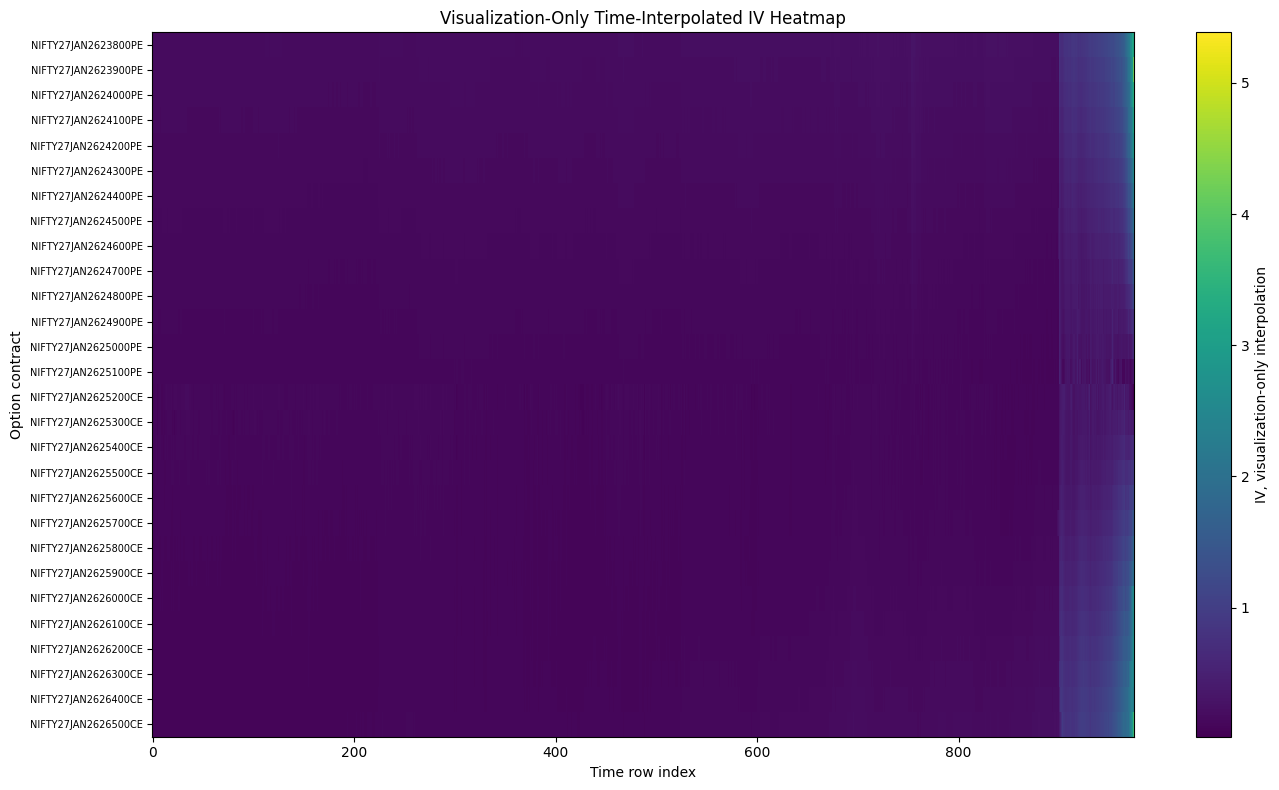

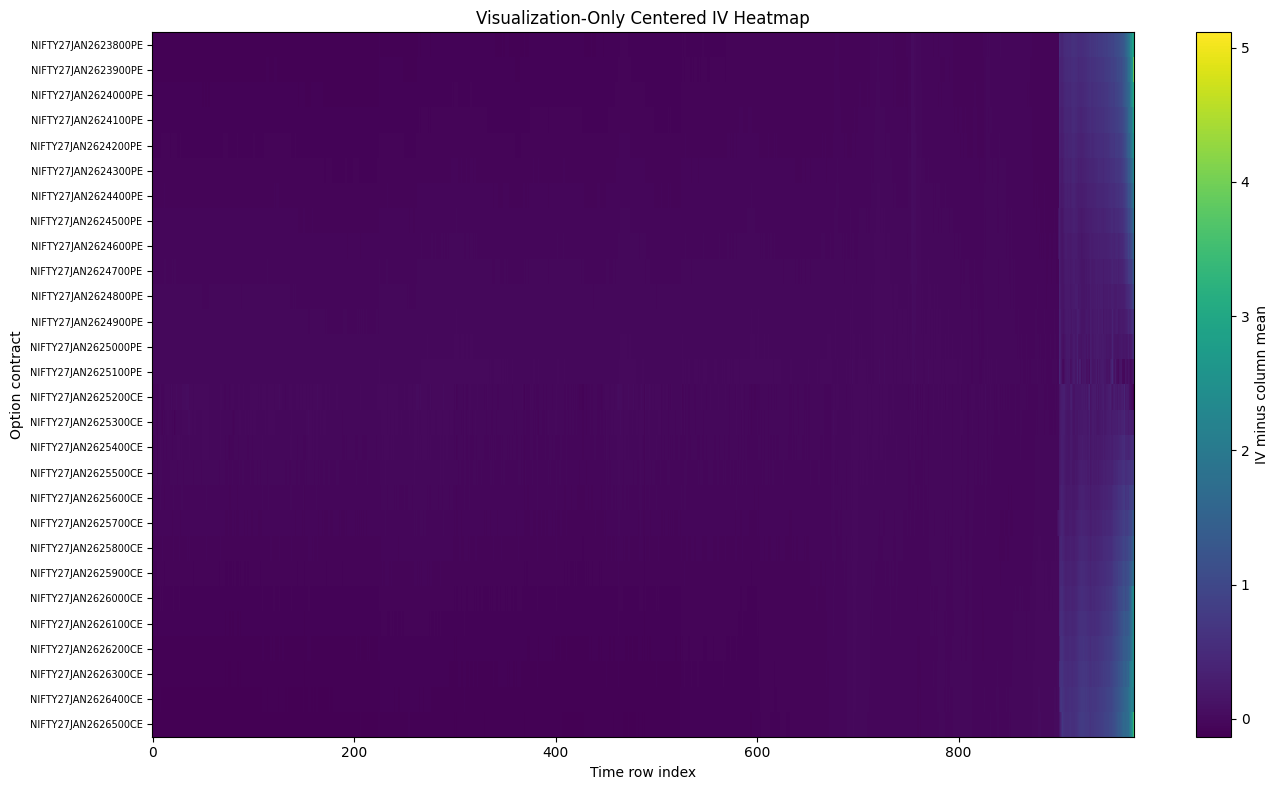

In [74]:
viz_iv = df[ordered_cols].copy()

# Simple time-direction interpolation for visualization only
viz_iv_interp = viz_iv.interpolate(method="linear", axis=0, limit_direction="both")

plt.figure(figsize=(14, 8))
plt.imshow(viz_iv_interp.T, aspect="auto", interpolation="nearest")
plt.title("Visualization-Only Time-Interpolated IV Heatmap")
plt.xlabel("Time row index")
plt.ylabel("Option contract")
plt.yticks(range(len(ordered_cols)), ordered_cols, fontsize=7)
plt.colorbar(label="IV, visualization-only interpolation")
plt.tight_layout()
plt.show()

# Difference from column means after visualization-only interpolation
viz_centered = viz_iv_interp - viz_iv_interp.mean(axis=0)

plt.figure(figsize=(14, 8))
plt.imshow(viz_centered.T, aspect="auto", interpolation="nearest")
plt.title("Visualization-Only Centered IV Heatmap")
plt.xlabel("Time row index")
plt.ylabel("Option contract")
plt.yticks(range(len(ordered_cols)), ordered_cols, fontsize=7)
plt.colorbar(label="IV minus column mean")
plt.tight_layout()
plt.show()

## 18. Compact EDA report tables

This cell produces report-style tables you can keep for a project README or modeling notes.

In [ ]:
report = {}

report["shape"] = df.shape
report["date_range"] = (df["datetime"].min(), df["datetime"].max())
report["trading_days"] = df["date"].nunique()
report["num_option_columns"] = len(option_cols)
report["num_call_columns"] = len(call_cols)
report["num_put_columns"] = len(put_cols)
report["overall_missing_rate"] = missing_iv_cells / total_iv_cells
report["iv_min"] = observed_iv_values.min()
report["iv_max"] = observed_iv_values.max()
report["underlying_min"] = df["underlying_price"].min()
report["underlying_max"] = df["underlying_price"].max()

print("===== EDA SUMMARY =====")
for k, v in report.items():
    print(f"{k}: {v}")

print("\n===== MISSINGNESS BY OPTION TYPE =====")
display(
    long.groupby("option_type")["is_missing"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "missing_rate", "sum": "missing_count", "count": "total_cells"})
)

print("\n===== IV SUMMARY BY OPTION TYPE =====")
display(
    observed_long.groupby("option_type")["iv"]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

print("\n===== STRIKE COVERAGE =====")
display(
    meta.groupby("option_type")["strike"]
    .agg(["min", "max", "count", "nunique"])
)

===== EDA SUMMARY =====
shape: (975, 41)
date_range: (Timestamp('2026-01-07 09:15:00'), Timestamp('2026-01-27 15:25:00'))
trading_days: 13
num_option_columns: 28
num_call_columns: 14
num_put_columns: 14
overall_missing_rate: 0.2
iv_min: 0.0168
iv_max: 5.38476
underlying_min: 24940.7
underlying_max: 26183.8

===== MISSINGNESS BY OPTION TYPE =====


,missing_rate,missing_count,total_cells
option_type,,,
CE,0.197143,2691,13650
PE,0.202857,2769,13650



===== IV SUMMARY BY OPTION TYPE =====


,count,mean,std,min,1%,5%,50%,95%,99%,max
option_type,,,,,,,,,,
CE,10959.0,0.166931,0.217520,0.01680,0.085866,0.09147,0.11156,0.537528,1.200579,3.74259
PE,10881.0,0.199059,0.219466,0.08191,0.104290,0.11267,0.15566,0.453850,1.087000,5.38476



===== STRIKE COVERAGE =====


,min,max,count,nunique
option_type,,,,
CE,25200,26500,14,14
PE,23800,25100,14,14


: 

## 19. Modeling notes from EDA

Use this section to write your own observations after running the notebook.

Suggested things to record:

1. **Missingness pattern**
   - Is it roughly uniform across columns?
   - Is one option type more missing?
   - Are edge strikes more missing?
   - Is missingness higher near expiry or at some time of day?

2. **Surface shape**
   - Are calls and puts smooth across strike?
   - Is there a clear skew?
   - Are there unstable timestamps?

3. **Time dynamics**
   - Does the whole surface move together?
   - Are IV spikes linked to underlying moves?
   - Does IV behavior change near expiry?

4. **No-static-arbitrage diagnostics**
   - Are observed prices mostly monotonic/convex?
   - Are violations rare enough to treat as noise?
   - Do violations cluster near expiry or in illiquid strikes?

5. **Look-ahead bias risk**
   - A live-style method should not use future rows to fill past missing values.
   - A matrix-completion method may score well but could be questioned if the host checks look-ahead.
   - Keep a clean, reproducible pipeline and document exactly what information each step uses.

6. **Potential future modeling directions**
   - Row-wise smile interpolation across moneyness
   - Time-series smoothing using only past/current data
   - Spline/SVI-style shape fitting
   - Robust handling of outliers
   - Optional no-arbitrage repair after converting IVs to prices

## 20. Final reminder

This notebook is for EDA only.

Before modeling, decide your allowed information set:

- **Strict no-lookahead version:** fill a missing value at time `t` using only data available at or before `t`, plus same-row observed options if allowed.
- **Kaggle matrix-imputation version:** use the full partially observed matrix, but this may be challenged if code checks look-ahead bias.

For this competition, because the host explicitly mentions look-ahead checks, it is smart to keep your final modeling code conservative and well documented.